# GARCH_분석 통합최종본

`GARCH_분석_통합최종.ipynb`와 `GARCH_EGARCH_비교분석.ipynb`를 하나의 분석 흐름으로 통합한 최종본

실행 구조:

```text
Step 1~8. GARCH-X 주 분석 및 한계점 개선
  → Model1~Model5 추정
  → alpha/beta SE 안정화
  → omega 민감도, 분산 처리 방식 강건성 확인

Step 9. 이벤트 더미 강건성 검증
  → 이벤트별 구조 차이 통제 가능성 확인

Step 10. EGARCH 강건성 검증
  → GARCH 기준선을 재추정하지 않고 기존 결과 재사용
  → 비대칭 변동성 구조에서도 GPR_custom 비유의 결론이 유지되는지 확인

Step 11~13. 시각화, 결과 저장, 최종 결론
```

EGARCH는 주모형 대체가 아니라, GARCH 기반 결론을 확인하는 강건성 검증 단계로 사용


# GARCH 분석 — 지정학 리스크와 BTC 변동성 (통합 최종본)
## 지정학적 위기 시 비트코인은 디지털 금인가?
### 캡스톤디자인 | 팀명: 분석많이된다

---

## 통합 기준

이 파일은 두 수정본의 장점을 모두 통합

| 항목 | 채택 출처 | 내용 |
|---|---|---|
| p-value SE | 한계점 개선본 | numdifftools Richardson 외삽법 → 정밀도 높음 |
| 다중 초기값 | 한계점 개선본 | 전체 5개 모델 × 10개 격자 탐색 |
| omega 하한 | 민진 수정본 | 0.05로 강화 → omega=0 과적합 완전 차단 |
| alpha 하한 | 민진 수정본 | 0.01로 설정 → 최소 충격 반응 강제 |
| 분산 강건성 | 민진 수정본 | clip + strict 두 방식 비교 |
| 파라미터 저장 | 민진 수정본 | garch_model_params.csv 전체 저장 |
| 파일 경로 | 한계점 개선본 | master_data.csv 동일 폴더 (경로 의존성 제거) |

## 5가지 모델

| 모델 | 외생변수 | 목적 |
|---|---|---|
| Model1 | GPR_zscore (공식 GPR) | 공식 GPR 벤치마크 |
| Model2 | GPR_custom (F3_z) | 자체 GPR 설명력 |
| Model3 | VIX + fear_greed_lag1 | 시장심리 설명력 |
| Model4 | GPR_zscore + VIX + F&G | 공식+심리 통합 |
| Model5 | GPR_custom + VIX + F&G | 커스텀+심리 통합 |

## GARCH-X 공식

```
수익률 방정식:
  r(t) = μ + ε(t),   ε(t) ~ Student-t(0, h(t), ν)

분산 방정식 (GARCH-X):
  h(t) = ω + α·ε²(t-1) + β·h(t-1) + γ·X(t-1)

  ω  : 기저 변동성 (항상 양수, ≥ 0.05)
  α  : 전일 충격의 오늘 영향 (ARCH 효과)
  β  : 전일 변동성 지속성 (GARCH 효과)
  γ  : 외생변수 효과 ← 핵심 분석 대상
  ν  : t분포 자유도 (팻테일 두께)
  X(t-1): 전일 외생변수 (어제 GPR → 오늘 변동성)
```

## γ 해석 기준

```
γ > 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↑ (위험자산 특성)
γ < 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↓ (안전자산 특성)
비유의        → GPR이 BTC 변동성을 통계적으로 설명하지 못함
```

## 필요 파일

```
master_data.csv   ← 이 파일과 동일 폴더에 있어야 함
```

## 실행 전 설치

```bash
pip install numdifftools
```

---
## Step 0. 라이브러리 및 환경 설정

### 라이브러리 역할

| 라이브러리 | 용도 |
|---|---|
| `pandas`, `numpy` | 데이터 처리 |
| `matplotlib` | 시각화 |
| `scipy.optimize.minimize` | GARCH 직접 MLE 최적화 (L-BFGS-B) |
| `scipy.special.gammaln` | Student-t 로그우도 계산 |
| `scipy.stats.t` | p-value 계산 |
| `numdifftools` | Hessian 수치 미분 (Richardson 외삽법) → SE 정밀 계산 |

### arch 라이브러리를 사용하지 않는 이유

```
arch_model(y, x=X, vol='GARCH')에서
  x= 파라미터는 분산식이 아닌 평균식에 투입됨
  → 외생변수가 변동성에 미반영
  → Model1~5 AIC가 모두 동일하게 출력되는 오류 발생

해결: scipy.optimize.minimize로 직접 MLE 구현
  h(t) = ω + α·ε²(t-1) + β·h(t-1) + γ·X(t-1)  ← 분산식에 직접 투입
```

In [1]:
# !pip install numdifftools --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import t as t_dist, zscore
import warnings, os, platform
warnings.filterwarnings('ignore')

# numdifftools (없으면 중앙차분법으로 자동 fallback)
try:
    import numdifftools as nd
    USE_NUMDIFF = True
    print('✅ numdifftools 사용 → Richardson 외삽법으로 SE 정밀 계산')
except ImportError:
    USE_NUMDIFF = False
    print('⚠️ numdifftools 없음 → 중앙차분법으로 SE 계산 (pip install numdifftools 권장)')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

# ── 이벤트 정의 (master_data.csv 이벤트명과 정확히 일치) ──
EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war'     : '2022-02-24',  # ✅ invasion 아님
    'israel_hamas_war'       : '2023-10-07',  # ✅ israel_hamas 아님
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war'     : '러-우 전쟁',
    'israel_hamas_war'       : '이스라엘-하마스 전쟁',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}
MODEL_EXOG = {
    'Model1': ['GPR_zscore_scaled'],
    'Model2': ['GPR_custom_scaled'],
    'Model3': ['VIX_scaled', 'fear_greed_lag1_scaled'],
    'Model4': ['GPR_zscore_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
    'Model5': ['GPR_custom_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
}
MODEL_LABELS = {
    'Model1': '공식 GPR 단독',
    'Model2': '커스텀 GPR 단독',
    'Model3': 'VIX + Fear&Greed',
    'Model4': '공식 GPR + 시장심리',
    'Model5': '커스텀 GPR + 시장심리',
}
MODEL_COLORS = {
    'Model1': '#E76F51', 'Model2': '#2A9D8F',
    'Model3': '#457B9D', 'Model4': '#F4A261', 'Model5': '#8338EC',
}

print('✅ 환경 설정 완료')
print(f'   모델 수: {len(MODEL_EXOG)}개')

✅ numdifftools 사용 → Richardson 외삽법으로 SE 정밀 계산
✅ 환경 설정 완료
   모델 수: 5개


---
## Step 1. master_data.csv 로드

### 사용 파일

```
master_data.csv  ← 이 노트북과 동일 폴더
```

### 포함 컬럼

| 컬럼 | 설명 |
|---|---|
| `BTC` | BTC 로그 수익률 |
| `GPR_custom` | 자체 제작 지정학 리스크 지수 (F3_z) |
| `GPR_zscore` | Caldara & Iacoviello(2022) 공식 GPR Z-score |
| `VIX` | 변동성 지수 (시장 공포) |
| `fear_greed_lag1` | 전일 탐욕·공포 지수 |
| `event_name` | 이벤트 이름 (EVENT_DATES 키와 일치해야 함) |

### 이벤트명 일치 확인

데이터의 `event_name`과 `EVENT_DATES`의 키가 정확히 일치해야 필터링·시각화가 정상 작동

In [3]:
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError(
        'master_data.csv 없음\n'
        '→ master_data_generated.ipynb를 먼저 실행해주세요.'
    )

master = pd.read_csv('master_data.csv')
master['date'] = pd.to_datetime(master['date'])

num_cols = ['BTC','Gold','TLT','DXY','SP500','NASDAQ',
            'GPR_custom','GPR','GPR_zscore',
            'VIX','fear_greed','fear_greed_lag1']
for col in num_cols:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

# GPR_zscore 없으면 GPR로 자동 생성
if 'GPR_zscore' not in master.columns and 'GPR' in master.columns:
    master['GPR_zscore'] = zscore(master['GPR'].fillna(master['GPR'].mean()))
    print('⚠️ GPR_zscore 없음 → GPR Z-score로 자동 생성')

print(f'✅ master_data: {len(master)}행')
print(f'   기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
print(f'\n이벤트별 거래일:')
print(master.groupby('event_name')['date'].count().sort_index().to_string())

# 이벤트명 일치 확인
missing = sorted(set(EVENT_DATES) - set(master['event_name'].dropna().unique()))
extra   = sorted(set(master['event_name'].dropna().unique()) - set(EVENT_DATES))
print(f'\n이벤트명 일치 확인:')
if not missing and not extra:
    print('  ✅ EVENT_DATES와 데이터 event_name 완전 일치')
else:
    if missing: print(f'  ❌ EVENT_DATES에만 있음: {missing}')
    if extra:   print(f'  ⚠️ 데이터에만 있음: {extra}')

✅ master_data: 1827행
   기간: 2019-01-02 ~ 2026-04-30

이벤트별 거래일:
event_name
hormuz_crisis              182
israel_hamas_war           260
israel_iran                299
russia_ukraine_war         475
soleimani_assassination    339
us_israel_iran             272

이벤트명 일치 확인:
  ✅ EVENT_DATES와 데이터 event_name 완전 일치


---
## Step 2. 분석 데이터 준비

### 처리 요약

| 항목 | 처리 방식 | 이유 |
|---|---|---|
| 종속변수 | `returns_pct = BTC × 100` | GARCH 수렴 안정화 (단위 맞춤) |
| 결측치 | `dropna()` 사용 | 없는 데이터를 0으로 채우면 추정 왜곡 |
| 외생변수 | Z-score 표준화 | 단위 통일, γ 계수를 '1σ 증가 효과'로 해석 가능 |
| 시차 | X(t-1) 사용 | 어제 GPR → 오늘 변동성 (내생성 문제 방지) |

### 표준화 점검 기준

```
mean ≈ 0,  std ≈ 1   → 정상
-0.0000, 1.0000      → 반올림 결과, 정상
```

### 이벤트 순서 정렬

```
master_data는 이벤트 이름으로 정렬되어 있어서
시간 순서대로 재정렬해야 GARCH 시계열이 올바르게 작동
```

In [4]:
# 이벤트 시간순 정렬
order = list(EVENT_DATES.keys())
master['_order'] = master['event_name'].map({ev:i for i,ev in enumerate(order)})
master_sorted = master.sort_values(['_order','date']).reset_index(drop=True)

# 결측치 제거 (fillna(0) 금지)
exog_cols_all = ['GPR_custom','GPR_zscore','VIX','fear_greed_lag1']
master_final  = master_sorted.dropna(subset=['BTC']+exog_cols_all).copy()
master_final  = master_final.reset_index(drop=True)

# 수익률 × 100
master_final['returns_pct'] = master_final['BTC'] * 100

# 외생변수 Z-score 표준화 (master_final 기준)
for col in exog_cols_all:
    mu, sig = master_final[col].mean(), master_final[col].std()
    master_final[f'{col}_scaled'] = (master_final[col]-mu)/sig if sig>0 else 0.0

print(f'✅ 분석 대상: {len(master_final)}거래일 (결측치 제거 후)')
print(f'\n이벤트별 분석 대상 거래일:')
print(master_final.groupby('event_name')['date'].count().sort_index().to_string())
print(f'\nBTC 수익률 기술통계 (×100):')
print(master_final['returns_pct'].describe().round(4))
print(f'\n외생변수 표준화 점검 (mean≈0, std≈1):')
scaled = [f'{c}_scaled' for c in exog_cols_all]
print(master_final[scaled].describe().loc[['mean','std']].round(4))

✅ 분석 대상: 1821거래일 (결측치 제거 후)

이벤트별 분석 대상 거래일:
event_name
hormuz_crisis              181
israel_hamas_war           259
israel_iran                298
russia_ukraine_war         474
soleimani_assassination    338
us_israel_iran             271

BTC 수익률 기술통계 (×100):
count    1821.0000
mean        0.1693
std         3.9545
min       -46.4730
25%        -1.6010
50%         0.0916
75%         1.9607
max        20.3046
Name: returns_pct, dtype: float64

외생변수 표준화 점검 (mean≈0, std≈1):
      GPR_custom_scaled  GPR_zscore_scaled  VIX_scaled  fear_greed_lag1_scaled
mean               -0.0                0.0         0.0                     0.0
std                 1.0                1.0         1.0                     1.0


---
## Step 3. Student-t GARCH-X 직접 MLE 함수

### 평균 방정식

```
r(t) = μ + ε(t)
```

### 분산 방정식 (GARCH-X)

```
h(t) = ω + α·ε²(t-1) + β·h(t-1) + γ·X(t-1)

파라미터 해석:
  ω (omega) : 기저 변동성 상수 (≥ 0.05 강제 → omega=0 과적합 방지)
  α (alpha) : 전일 충격 반응 (ARCH 효과, ≥ 0.01)
  β (beta)  : 변동성 지속성 (GARCH 효과, 정상: 0.80~0.95)
  α+β       : 1에 가까울수록 충격이 오래 지속 (반드시 < 1)
  γ (gamma) : 외생변수 효과 ← 핵심 분석 대상
  ν (nu)    : t분포 자유도, 낮을수록 팻테일 두꺼움 (> 2)
```

### 오차항 분포 — Student-t

```
ε(t)/√h(t) ~ standardized Student-t(ν)

정규분포 대신 t분포를 쓰는 이유:
  BTC는 폭등·폭락 같은 극단 수익률이 정규분포보다 훨씬 빈번
  → 팻테일(fat-tail) 현상
  → t분포가 이를 더 정확하게 반영
```

### bounds 설정 근거

| 파라미터 | 제약 | 근거 |
|---|---|---|
| ω (omega) | ≥ 0.05 | 0 수렴 방지 → 과적합 차단 |
| α (alpha) | 0.01 ~ 0.5 | 최소 충격 반응 보장, 비정상 t-stat 완화 |
| β (beta) | 0.3 ~ 0.999 | 지속성 범위 제한 |
| ν (nu) | 2.01 ~ 50 | t분포 분산 존재 조건 (> 2) |

### 분산 처리 방식 2가지

| 방식 | h(t) ≤ 1e-8 발생 시 | 용도 |
|---|---|---|
| `clip` | h(t) = 1e-8로 보정 | 기본 분석용 |
| `strict` | 해당 파라미터 후보 탈락 | 강건성 확인용 |

### 다중 초기값 전략

```
모든 모델: alpha 5개 × beta 2개 = 10가지 초기값 격자 탐색
  → 국소최적해 탈출 가능성 대폭 향상
  → 가장 낮은 음의 로그우도(= 가장 높은 LogLik) 결과 채택
```

In [5]:
def student_t_neg_loglik(params, y_vals, X_lag, variance_mode='clip'):
    """
    Student-t GARCH-X 음의 로그우도 함수

    variance_mode='clip'  : h_t <= 1e-8이면 1e-8로 보정 (기본값)
    variance_mode='strict': h_t <= 1e-8이면 페널티 반환 (강건성 확인)
    """
    T  = len(y_vals)
    K  = X_lag.shape[1]
    mu, omega, alpha, beta = params[0], params[1], params[2], params[3]
    gamma = params[4:4+K]
    nu    = params[4+K]

    if omega <= 0 or alpha < 0 or beta < 0: return 1e10
    if alpha + beta >= 0.9999:              return 1e10
    if nu <= 2.01:                          return 1e10

    e    = y_vals - mu
    h    = np.empty(T)
    h[0] = max(np.var(e), 1e-8)

    for t in range(1, T):
        eff  = np.dot(gamma, X_lag[t]) if K > 0 else 0.0
        h[t] = omega + alpha*e[t-1]**2 + beta*h[t-1] + eff
        if h[t] <= 1e-8 or not np.isfinite(h[t]):
            if variance_mode == 'clip':   h[t] = 1e-8
            elif variance_mode == 'strict': return 1e10

    ll = (
        gammaln((nu+1)/2) - gammaln(nu/2)
        - 0.5*np.log(np.pi*(nu-2))
        - 0.5*np.log(h)
        - ((nu+1)/2)*np.log(1 + e**2/((nu-2)*h))
    )
    return -np.sum(ll) if np.isfinite(np.sum(ll)) else 1e10


def fit_garch_x(y_series, exog_df, model_exog_cols,
                model_name='Model', variance_mode='clip'):
    """
    GARCH(1,1)-X 직접 MLE 추정

    개선사항:
    - omega 하한 0.05 (과적합 차단)
    - alpha 하한 0.01 (경계수렴 완화)
    - 전체 모델 10개 초기값 격자 탐색 (국소최적해 회피)
    - cond_vol 직접 재계산해서 저장 (arch 속성 의존 제거)
    """
    actual_cols = [c for c in model_exog_cols if c in exog_df.columns]
    miss = [c for c in model_exog_cols if c not in exog_df.columns]
    if miss: print(f'  ⚠️ [{model_name}] 없는 컬럼: {miss}')
    print(f'\n[{model_name}] 외생변수: {actual_cols}')

    y      = y_series.dropna().astype(np.float64)
    y_idx  = y.index
    y_vals = y.values
    T, K   = len(y_vals), len(actual_cols)

    if K > 0:
        X_raw = exog_df.loc[y_idx, actual_cols].ffill().fillna(0).astype(np.float64)
        X_lag = X_raw.shift(1).fillna(0).values  # X(t-1)
    else:
        X_lag = np.zeros((T, 0))

    obj = lambda p: student_t_neg_loglik(p, y_vals, X_lag, variance_mode)

    # bounds (통합: omega≥0.05, alpha≥0.01)
    bounds = (
        [(None, None)]     # mu
        + [(0.05, None)]   # omega ≥ 0.05 (민진본 채택)
        + [(0.01, 0.5)]    # alpha ≥ 0.01 (민진본 채택)
        + [(0.3,  0.999)]  # beta
        + [(None, None)]*K # gamma
        + [(2.01, 50.0)]   # nu
    )

    # 다중 초기값 10개 격자 (한계점 개선본 채택: 전체 모델)
    alpha_inits = [0.05, 0.08, 0.10, 0.15, 0.20]
    beta_inits  = [0.80, 0.90]
    init_grid   = [
        [np.mean(y_vals), max(np.var(y_vals)*0.05, 0.05), a, b]
        + [0.001]*K + [5.0]
        for a in alpha_inits for b in beta_inits
    ]
    print(f'  초기값 격자: {len(init_grid)}개 탐색 중...')

    best_result, best_val = None, np.inf
    for init in init_grid:
        try:
            res = minimize(obj, init, method='L-BFGS-B', bounds=bounds,
                           options={'maxiter':5000,'ftol':1e-14,'gtol':1e-8})
            if res.fun < best_val:
                best_val, best_result = res.fun, res
        except Exception:
            continue

    if best_result is None:
        print(f'  ❌ [{model_name}] 모든 초기값 실패')
        return {'result':None,'error':'최적화 실패','exog_cols':actual_cols,
                'y_index':y_idx,'X_lag':X_lag,'cond_vol':None}

    p = best_result.x
    n_params     = len(p)
    loglik       = -best_val
    aic          = -2*loglik + 2*n_params
    bic          = -2*loglik + n_params*np.log(T)
    param_names  = (['mu','omega','alpha','beta']
                    + [f'gamma({c})' for c in actual_cols] + ['nu'])
    params_dict  = dict(zip(param_names, p))

    # 추정 결과 출력
    print(f'  {"-"*56}')
    print(f'  ▶ [{model_name}] 추정 결과')
    print(f'  {"-"*56}')
    for nm, val in params_dict.items():
        print(f'  {nm:<28} {val:>12.5f}')
    print(f'  {"-"*56}')
    print(f'  LogLik={loglik:.3f}  AIC={aic:.3f}  BIC={bic:.3f}')
    print(f'  수렴={"✅" if best_result.success else "⚠️"}  '
          f'alpha+beta={p[2]+p[3]:.4f}')

    # cond_vol 직접 재계산 (arch .conditional_volatility 의존 제거)
    e    = y_vals - p[0]
    h    = np.empty(T)
    h[0] = max(np.var(e), 1e-8)
    for t in range(1, T):
        eff  = np.dot(p[4:4+K], X_lag[t]) if K > 0 else 0.0
        h[t] = max(p[1]+p[2]*e[t-1]**2+p[3]*h[t-1]+eff, 1e-8)

    return {
        'result'     : best_result,
        'neg_loglik' : obj,           # p-value 계산용 클로저
        'T'          : T, 'K': K,
        'params'     : params_dict,
        'param_names': param_names,
        'exog_cols'  : actual_cols,
        'aic'        : aic, 'bic': bic, 'loglik': loglik,
        'converged'  : best_result.success,
        'cond_vol'   : np.sqrt(h),    # 조건부 변동성 σ(t)
        'y_index'    : y_idx,
        'X_lag'      : X_lag,
        'error'      : None,
    }


print('✅ fit_garch_x() 정의 완료')
print(f'  초기값 격자: alpha {[0.05,0.08,0.10,0.15,0.20]} × beta {[0.80,0.90]} = 10가지')

✅ fit_garch_x() 정의 완료
  초기값 격자: alpha [0.05, 0.08, 0.1, 0.15, 0.2] × beta [0.8, 0.9] = 10가지


---
## Step 4. Model1~Model5 추정 (clip 방식)

### 추정 흐름

```
1. 각 모델의 외생변수 컬럼 확인
2. X(t-1) lag 생성
3. 10개 초기값으로 L-BFGS-B 최적화
4. 최저 음의 로그우도 결과 채택
5. 조건부 변동성 σ(t) 재계산
```

### 비교 기준

```
LogLik : 높을수록 좋음 (데이터 설명력)
AIC    : 낮을수록 좋음 (설명력 - 파라미터 수 페널티)
BIC    : 낮을수록 좋음 (AIC보다 파라미터 수 페널티 강함)
α+β    : 1에 가까울수록 충격 지속성 큼 (반드시 < 1)
```

In [6]:
garch_results = {}
print('='*65)
print('▶ GARCH(1,1)-X 추정 (직접 MLE | Student-t | X(t-1) 시차)')
print('='*65)

for mname, exog_cols in MODEL_EXOG.items():
    res = fit_garch_x(
        master_final['returns_pct'],
        master_final, exog_cols,
        model_name=mname, variance_mode='clip'
    )
    garch_results[mname] = res

print('\n' + '='*55)
print('▶ 모델 비교 요약')
print('='*55)
print(f'{"모델":<10} {"LogLik":>10} {"AIC":>10} {"BIC":>10} {"α+β":>6} {"수렴":>5}')
print('-'*55)
for mname, res in garch_results.items():
    if res.get('error') or res.get('aic') is None: continue
    ab = res['params'].get('alpha',0)+res['params'].get('beta',0)
    cv = '✅' if res['converged'] else '⚠️'
    print(f'{mname:<10} {res["loglik"]:>10.3f} '
          f'{res["aic"]:>10.3f} {res["bic"]:>10.3f} {ab:>6.4f} {cv:>5}')

▶ GARCH(1,1)-X 추정 (직접 MLE | Student-t | X(t-1) 시차)

[Model1] 외생변수: ['GPR_zscore_scaled']
  초기값 격자: 10개 탐색 중...
  --------------------------------------------------------
  ▶ [Model1] 추정 결과
  --------------------------------------------------------
  mu                                0.08879
  omega                             0.44150
  alpha                             0.08076
  beta                              0.91295
  gamma(GPR_zscore_scaled)         -0.00450
  nu                                2.99911
  --------------------------------------------------------
  LogLik=-4785.259  AIC=9582.517  BIC=9615.560
  수렴=✅  alpha+beta=0.9937

[Model2] 외생변수: ['GPR_custom_scaled']
  초기값 격자: 10개 탐색 중...
  --------------------------------------------------------
  ▶ [Model2] 추정 결과
  --------------------------------------------------------
  mu                                0.08855
  omega                             0.44319
  alpha                             0.08082
  beta                     

---
## Step 5. 표준오차 및 p-value 계산

### 계산 원리

```
분산-공분산 행렬 = [Hessian of -LogLik]⁻¹
SE = sqrt(diag(Cov))
t  = 추정값 / SE
p  = 2 × (1 - t분포 CDF)  (양측검정)
```

### Hessian 계산 방법 비교

| 방법 | 정밀도 | 비고 |
|---|---|---|
| 변환 파라미터 Hessian + delta method | 높음 | omega/alpha/beta/nu 제약을 unconstrained 공간에서 계산 후 원 파라미터 SE 복원 |
| numdifftools Richardson 외삽법 | 높음 | 변환 파라미터 공간의 Hessian 계산에 사용 |
| 중앙차분법 eps=1e-4 | 보통 | numdifftools 없을 때 fallback |

### 주의사항

```
기존 직접 Hessian 방식은 bounds 근처에서 alpha/beta SE가 0으로 붙을 수 있음
→ 변환 파라미터 Hessian + delta method로 비정상 t-stat 완화

단, alpha+beta가 1에 가까우면 beta t-stat은 여전히 크게 나올 수 있음
→ 수치 오류라기보다 near-IGARCH, 즉 변동성 지속성이 강한 구조로 해석

GARCH likelihood 특성상 Hessian이 불안정할 수 있음
→ p-value는 보조 기준으로 활용, AIC/BIC·계수 방향과 함께 해석
```

In [7]:
def _sigmoid(x):
    x = np.clip(x, -40, 40)
    return 1.0 / (1.0 + np.exp(-x))


def _logit(p):
    p = np.clip(p, 1e-8, 1-1e-8)
    return np.log(p / (1-p))


def _raw_to_direct(raw, K, omega_lb=0.05):
    """
    unconstrained raw parameter -> original GARCH parameter

    목적:
    - omega > omega_lb
    - alpha >= 0, beta >= 0
    - alpha + beta < 0.999
    - nu > 2.01
    위 제약을 최적화/SE 계산 과정에서 구조적으로 보장한다.
    """
    mu = raw[0]
    omega = omega_lb + np.exp(np.clip(raw[1], -40, 40))

    persistence = 0.999 * _sigmoid(raw[2])
    share = _sigmoid(raw[3])
    alpha = persistence * share
    beta = persistence * (1-share)

    gamma = raw[4:4+K]
    nu = 2.01 + 47.99 * _sigmoid(raw[4+K])
    return np.r_[mu, omega, alpha, beta, gamma, nu]


def _direct_to_raw(params, K, omega_lb=0.05):
    """original GARCH parameter -> unconstrained raw parameter"""
    alpha, beta = params[2], params[3]
    persistence = np.clip(alpha + beta, 1e-8, 0.998999)
    share = np.clip(alpha / persistence, 1e-8, 1-1e-8)

    return np.r_[
        params[0],
        np.log(max(params[1] - omega_lb, 1e-8)),
        _logit(persistence / 0.999),
        _logit(share),
        params[4:4+K],
        _logit((params[4+K] - 2.01) / 47.99),
    ]


def _transformed_jacobian(raw, K, omega_lb=0.05):
    """Jacobian d(original params) / d(raw params), delta method용"""
    n = 5 + K
    J = np.zeros((n, n))
    J[0, 0] = 1.0
    J[1, 1] = np.exp(np.clip(raw[1], -40, 40))

    s_p = _sigmoid(raw[2])
    persistence = 0.999 * s_p
    d_persistence = 0.999 * s_p * (1-s_p)

    s_share = _sigmoid(raw[3])
    d_share = s_share * (1-s_share)

    J[2, 2] = d_persistence * s_share
    J[2, 3] = persistence * d_share
    J[3, 2] = d_persistence * (1-s_share)
    J[3, 3] = -persistence * d_share

    for i in range(K):
        J[4+i, 4+i] = 1.0

    s_nu = _sigmoid(raw[4+K])
    J[4+K, 4+K] = 47.99 * s_nu * (1-s_nu)
    return J


def _hessian_numeric(func, x):
    """numdifftools 우선, 실패 시 중앙차분 fallback"""
    n = len(x)
    if USE_NUMDIFF:
        try:
            H = nd.Hessian(func, method='central')(x)
            return H, '변환 파라미터 Hessian + numdifftools Richardson'
        except Exception as e:
            print(f'  ⚠️ 변환 Hessian numdifftools 실패 ({e}) → 중앙차분법 사용')

    eps = 1e-4
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            p_pp=x.copy(); p_pp[i]+=eps; p_pp[j]+=eps
            p_pm=x.copy(); p_pm[i]+=eps; p_pm[j]-=eps
            p_mp=x.copy(); p_mp[i]-=eps; p_mp[j]+=eps
            p_mm=x.copy(); p_mm[i]-=eps; p_mm[j]-=eps
            H[i,j]=(func(p_pp)-func(p_pm)-func(p_mp)+func(p_mm))/(4*eps**2)
    return H, '변환 파라미터 Hessian + 중앙차분법 eps=1e-4'


def compute_pvalues(opt_result, neg_loglik_func, params_dict, T, omega_lb=0.05):
    """
    SE·t-stat·p-value 계산

    개선 방식:
    1. bounds가 걸린 원 파라미터에서 직접 Hessian을 계산하지 않음
    2. omega/alpha/beta/nu 제약을 unconstrained raw parameter로 변환
    3. raw parameter 공간에서 Hessian 계산
    4. delta method로 원 파라미터의 SE 복원

    효과:
    - alpha/beta가 경계가 아닌데도 SE=0으로 붙는 비정상 t-stat 문제 완화
    - gamma p-value는 기존 해석과 거의 동일하게 유지
    """
    params      = opt_result.x
    n_params    = len(params)
    K           = n_params - 5
    param_names = list(params_dict.keys())

    raw_params = _direct_to_raw(params, K, omega_lb=omega_lb)
    raw_obj    = lambda raw: neg_loglik_func(_raw_to_direct(raw, K, omega_lb=omega_lb))

    try:
        H_raw, method_used = _hessian_numeric(raw_obj, raw_params)
        hessian_cond = np.linalg.cond(H_raw)
        try:
            cov_raw = np.linalg.inv(H_raw)
            inv_method = 'inverse'
        except np.linalg.LinAlgError:
            cov_raw = np.linalg.pinv(H_raw)
            inv_method = 'pseudo-inverse'

        if not np.all(np.isfinite(cov_raw)):
            cov_raw = np.linalg.pinv(H_raw)
            inv_method = 'pseudo-inverse'

        J = _transformed_jacobian(raw_params, K, omega_lb=omega_lb)
        cov = J @ cov_raw @ J.T
        diag = np.diag(cov)
        se = np.sqrt(np.where(diag > 0, diag, np.nan))
    except Exception as e:
        print(f'  ⚠️ 변환 파라미터 SE 계산 실패 ({e}) → 기존 직접 Hessian 방식 fallback')
        H_raw, method_used = _hessian_numeric(neg_loglik_func, params)
        hessian_cond = np.linalg.cond(H_raw)
        try:
            cov = np.linalg.inv(H_raw)
            inv_method = 'inverse'
        except np.linalg.LinAlgError:
            cov = np.linalg.pinv(H_raw)
            inv_method = 'pseudo-inverse'
        se = np.sqrt(np.abs(np.diag(cov)))

    t_stats = params / se
    df      = max(T - n_params, 1)
    p_vals  = 2*(1 - t_dist.cdf(np.abs(t_stats), df=df))

    pv_list = list(params_dict.values())
    print(f'  SE 계산: {method_used}')
    print(f'  Hessian 조건수: {hessian_cond:.2e} | 역행렬: {inv_method}')
    print(f"  {'파라미터':<28} {'추정값':>9} {'SE':>9} "
          f"{'t-stat':>9} {'p-value':>10} {'유의'}")
    print(f"  {'─'*80}")
    for nm, val, s, t, p in zip(param_names,pv_list,se,t_stats,p_vals):
        sig = ('***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else '')
        if not np.isfinite(s) or not np.isfinite(t):
            t_str = '  N/A(수치)'
            sig = '⚠️'
        else:
            t_str = f'{t:>9.3f}' if abs(t)<=100 else '  N/A(경계)'
            if abs(t) > 100: sig = '⚠️'
        print(f"  {nm:<28} {val:>9.4f} {s:>9.4f} {t_str} {p:>10.4f} {sig}")
    print('  유의성: *** p<0.01  ** p<0.05  * p<0.10  ⚠️=t-stat 이상/수치불안정')

    return {
        'se':se,
        't_stats':t_stats,
        'p_values':p_vals,
        'param_names':param_names,
        'se_method':method_used,
        'hessian_condition':hessian_cond,
        'inv_method':inv_method,
    }


for mname, res in garch_results.items():
    if res.get('error') or res.get('result') is None: continue
    print(f'\n{"="*72}')
    print(f'  [{mname}] {MODEL_LABELS[mname]} — p-value 검정')
    print(f'{"="*72}')
    stat = compute_pvalues(
        opt_result      = res['result'],
        neg_loglik_func = res['neg_loglik'],
        params_dict     = res['params'],
        T               = res['T'],
    )
    garch_results[mname]['stats'] = stat



  [Model1] 공식 GPR 단독 — p-value 검정
  SE 계산: 변환 파라미터 Hessian + numdifftools Richardson
  Hessian 조건수: 2.10e+03 | 역행렬: inverse
  파라미터                               추정값        SE    t-stat    p-value 유의
  ────────────────────────────────────────────────────────────────────────────────
  mu                              0.0888    0.0634     1.399     0.1619 
  omega                           0.4415    0.1685     2.620     0.0089 ***
  alpha                           0.0808    0.0200     4.048     0.0001 ***
  beta                            0.9129    0.0181    50.486     0.0000 ***
  gamma(GPR_zscore_scaled)       -0.0045    0.0902    -0.050     0.9602 
  nu                              2.9991    0.2541    11.804     0.0000 ***
  유의성: *** p<0.01  ** p<0.05  * p<0.10  ⚠️=t-stat 이상/수치불안정

  [Model2] 커스텀 GPR 단독 — p-value 검정
  SE 계산: 변환 파라미터 Hessian + numdifftools Richardson
  Hessian 조건수: 2.03e+03 | 역행렬: inverse
  파라미터                               추정값        SE    t-stat    p-value 유의
  ─────

---
## Step 6. 외생변수 γ 계수 요약

### γ 해석 가이드

```
γ > 0 & p<0.05  → 외생변수↑ 시 BTC 변동성 증가 (위험자산 특성)
γ < 0 & p<0.05  → 외생변수↑ 시 BTC 변동성 감소 (안전자산 특성)
γ > 0 & p<0.10  → 약한 변동성 증가 경향
비유의           → 해당 변수가 BTC 변동성을 통계적으로 설명 못함
⚠️ 경계수렴      → t-stat 이상 (alpha=0 경계) → 신뢰 불가
```

### 핵심 해석 대상

```
Model2, Model5의 gamma(GPR_custom_scaled)
→ 우리가 만든 GPR이 BTC 변동성을 유의하게 설명하는가?
```

In [8]:
gamma_rows = []
print('▶ 외생변수 γ 계수 요약\n')
print(f'{"모델":<10} {"변수":<28} {"γ":>10} '
      f'{"p-value":>10} {"유의":<12} {"해석"}')
print('-'*90)

for mname, res in garch_results.items():
    if res.get('error') or res.get('stats') is None: continue
    param_names = res['param_names']
    params_dict = res['params']
    p_values    = res['stats']['p_values']
    t_stats     = res['stats']['t_stats']

    for i, pname in enumerate(param_names):
        if not pname.startswith('gamma('): continue
        vname = pname[6:-1]
        coef  = params_dict[pname]
        pv    = p_values[i]
        ts    = t_stats[i]

        if abs(ts) > 100:
            sig, interp = '⚠️ 경계수렴', '신뢰 불가 (alpha=0 경계)'
        elif pv < 0.05:
            sig    = '✅ p<0.05'
            interp = '변동성 증가 (위험자산)' if coef>0 else '변동성 감소 (안전자산)'
        elif pv < 0.10:
            sig    = '△ p<0.10'
            interp = '변동성 증가 경향' if coef>0 else '변동성 감소 경향'
        else:
            sig, interp = '— 비유의', '비유의'

        print(f'{mname:<10} {vname:<28} {coef:>10.5f} '
              f'{pv:>10.4f} {sig:<12} {interp}')
        gamma_rows.append({
            'model': mname, 'model_label': MODEL_LABELS[mname],
            'variable': vname, 'gamma': round(coef,5),
            'p_value': round(pv,4), 'significance': sig, 'interpretation': interp
        })

gamma_df = pd.DataFrame(gamma_rows)
display(gamma_df)

▶ 외생변수 γ 계수 요약

모델         변수                                    γ    p-value 유의           해석
------------------------------------------------------------------------------------------
Model1     GPR_zscore_scaled              -0.00450     0.9602 — 비유의        비유의
Model2     GPR_custom_scaled               0.02627     0.7346 — 비유의        비유의
Model3     VIX_scaled                     -0.02308     0.8007 — 비유의        비유의
Model3     fear_greed_lag1_scaled          0.15725     0.0375 ✅ p<0.05     변동성 증가 (위험자산)
Model4     GPR_zscore_scaled               0.04404     0.5833 — 비유의        비유의
Model4     VIX_scaled                     -0.03038     0.7315 — 비유의        비유의
Model4     fear_greed_lag1_scaled          0.16668     0.0324 ✅ p<0.05     변동성 증가 (위험자산)
Model5     GPR_custom_scaled               0.03637     0.5962 — 비유의        비유의
Model5     VIX_scaled                     -0.02472     0.7875 — 비유의        비유의
Model5     fear_greed_lag1_scaled          0.16154     0.0339 ✅ p<0.05     변동성 증가 (위

,model,model_label,variable,gamma,p_value,significance,interpretation
0,Model1,공식 GPR 단독,GPR_zscore_scaled,-0.00450,0.9602,— 비유의,비유의
1,Model2,커스텀 GPR 단독,GPR_custom_scaled,0.02627,0.7346,— 비유의,비유의
2,Model3,VIX + Fear&Greed,VIX_scaled,-0.02308,0.8007,— 비유의,비유의
3,Model3,VIX + Fear&Greed,fear_greed_lag1_scaled,0.15725,0.0375,✅ p<0.05,변동성 증가 (위험자산)
4,Model4,공식 GPR + 시장심리,GPR_zscore_scaled,0.04404,0.5833,— 비유의,비유의
5,Model4,공식 GPR + 시장심리,VIX_scaled,-0.03038,0.7315,— 비유의,비유의
6,Model4,공식 GPR + 시장심리,fear_greed_lag1_scaled,0.16668,0.0324,✅ p<0.05,변동성 증가 (위험자산)
7,Model5,커스텀 GPR + 시장심리,GPR_custom_scaled,0.03637,0.5962,— 비유의,비유의
8,Model5,커스텀 GPR + 시장심리,VIX_scaled,-0.02472,0.7875,— 비유의,비유의
9,Model5,커스텀 GPR + 시장심리,fear_greed_lag1_scaled,0.16154,0.0339,✅ p<0.05,변동성 증가 (위험자산)


---
## Step 7. 모델 비교 (AIC / BIC)

### 비교 기준

```
AIC = -2 × LogLik + 2 × k     (k: 파라미터 수)
BIC = -2 × LogLik + k × ln(T) (T: 관측치 수)

낮을수록 좋은 모델 (설명력 대비 복잡도 페널티 포함)
BIC는 AIC보다 파라미터 수 페널티가 더 강함
```

### 해석 주의사항

```
AIC 최저 ≠ 경제적 결론 확정

함께 확인해야 할 것:
  ① γ 계수 방향과 유의성
  ② alpha+beta 수준 (지속성)
  ③ 수렴 여부
  ④ 표본 수 한계 (~1,800행)
```

In [9]:
rows = []
for mname, res in garch_results.items():
    if res.get('error') or res.get('aic') is None: continue
    p = res['result'].x
    rows.append({
        '모델'    : mname,
        '설명'    : MODEL_LABELS.get(mname,mname),
        '외생변수': ', '.join(res['exog_cols']),
        'AIC'     : round(res['aic'],3),
        'BIC'     : round(res['bic'],3),
        'Log-Lik' : round(res['loglik'],3),
        'α+β'     : round(p[2]+p[3],4),
        '수렴'    : '✅' if res.get('converged') else '⚠️',
    })

compare_df = pd.DataFrame(rows).set_index('모델').sort_values('AIC')
print('▶ 모델 비교 (AIC 오름차순):\n')
display(compare_df)
best = compare_df.index[0]
print(f'\n✅ AIC 기준 최적 모델: {best}  ({MODEL_LABELS[best]})')

▶ 모델 비교 (AIC 오름차순):



,설명,외생변수,AIC,BIC,Log-Lik,α+β,수렴
모델,,,,,,,
Model3,VIX + Fear&Greed,"VIX_scaled, fear_greed_lag1_scaled",9578.710,9617.260,-4782.355,0.9961,✅
Model4,공식 GPR + 시장심리,"GPR_zscore_scaled, VIX_scaled, fear_greed_lag1...",9580.390,9624.447,-4782.195,0.9975,✅
Model5,커스텀 GPR + 시장심리,"GPR_custom_scaled, VIX_scaled, fear_greed_lag1...",9580.417,9624.474,-4782.208,0.9960,✅
Model2,커스텀 GPR 단독,GPR_custom_scaled,9582.402,9615.445,-4785.201,0.9937,✅
Model1,공식 GPR 단독,GPR_zscore_scaled,9582.517,9615.560,-4785.259,0.9937,✅



✅ AIC 기준 최적 모델: Model3  (VIX + Fear&Greed)


---
## Step 8. 분산 처리 방식 강건성 확인

### 목적

```
clip 방식  : h(t) < 0이면 1e-8로 보정 → 기본 분석
strict 방식: h(t) < 0이면 해당 후보 탈락 → 강건성 확인

두 방식에서 최적 모델이 동일하면
  → 결과가 분산 처리 방식에 민감하지 않음 → 신뢰도 보강

두 방식에서 최적 모델이 다르면
  → 분산 처리 방식에 민감한 결과 → 주의 필요
```

In [10]:
strict_results = {}
print('='*65)
print('▶ strict 방식 강건성 확인 (h(t)<0이면 후보 탈락)')
print('='*65)

for mname, exog_cols in MODEL_EXOG.items():
    res = fit_garch_x(
        master_final['returns_pct'],
        master_final, exog_cols,
        model_name=f'{mname}_strict', variance_mode='strict'
    )
    strict_results[mname] = res

# 비교표
strict_rows = []
for mname, res in strict_results.items():
    if res.get('error') or res.get('aic') is None: continue
    strict_rows.append({'model':mname,'AIC_strict':round(res['aic'],3),
                        'BIC_strict':round(res['bic'],3)})

strict_df = pd.DataFrame(strict_rows)
if len(strict_df) > 0 and len(compare_df) > 0:
    compare_reset = compare_df.reset_index()[['모델','AIC','BIC']].rename(
        columns={'모델':'model','AIC':'AIC_clip','BIC':'BIC_clip'})
    merged = compare_reset.merge(strict_df, on='model', how='left')
    merged['ΔAIC'] = merged['AIC_strict'] - merged['AIC_clip']
    print('\n▶ clip vs strict AIC 비교:\n')
    display(merged.round(3))

    best_clip   = compare_df.index[0]
    best_strict = (strict_df.sort_values('AIC_strict').iloc[0]['model']
                   if len(strict_df)>0 else None)
    print(f'\n  clip 기준 최적: {best_clip}')
    print(f'  strict 기준 최적: {best_strict}')
    if best_clip == best_strict:
        print('  ✅ 동일 → 분산 처리 방식에 강건한 결과')
    else:
        print('  ⚠️ 다름 → 분산 처리 방식에 민감 → 해석 주의 필요')

▶ strict 방식 강건성 확인 (h(t)<0이면 후보 탈락)

[Model1_strict] 외생변수: ['GPR_zscore_scaled']
  초기값 격자: 10개 탐색 중...
  --------------------------------------------------------
  ▶ [Model1_strict] 추정 결과
  --------------------------------------------------------
  mu                                0.08879
  omega                             0.44150
  alpha                             0.08076
  beta                              0.91295
  gamma(GPR_zscore_scaled)         -0.00450
  nu                                2.99911
  --------------------------------------------------------
  LogLik=-4785.259  AIC=9582.517  BIC=9615.560
  수렴=✅  alpha+beta=0.9937

[Model2_strict] 외생변수: ['GPR_custom_scaled']
  초기값 격자: 10개 탐색 중...
  --------------------------------------------------------
  ▶ [Model2_strict] 추정 결과
  --------------------------------------------------------
  mu                                0.08855
  omega                             0.44320
  alpha                             0.08082
  beta        

,model,AIC_clip,BIC_clip,AIC_strict,BIC_strict,ΔAIC
0,Model3,9578.710,9617.260,9578.710,9617.260,0.0
1,Model4,9580.390,9624.447,9580.390,9624.447,0.0
2,Model5,9580.417,9624.474,9580.417,9624.474,0.0
3,Model2,9582.402,9615.445,9582.402,9615.445,0.0
4,Model1,9582.517,9615.560,9582.517,9615.560,0.0



  clip 기준 최적: Model3
  strict 기준 최적: Model3
  ✅ 동일 → 분산 처리 방식에 강건한 결과


---
## Step 9. 이벤트 더미 강건성 검증

### 목적

```
기존 데이터는 서로 떨어진 이벤트 구간을 하나의 시계열처럼 이어붙임
→ 이벤트 사이 실제 시간 공백이 GARCH 과정에 반영되지 않음

현재 데이터 내 보완: 이벤트 더미를 분산식에 추가해 이벤트별 구조 차이를 통제
```

### 추가되는 이벤트 더미

기준 이벤트는 `hormuz_crisis`이며, 나머지 이벤트가 0/1 더미로 추가

| 더미 | 의미 |
|---|---|
| `event_israel_hamas_war` | 이스라엘-하마스 전쟁 구간 |
| `event_israel_iran` | 이스라엘-이란 충돌 구간 |
| `event_russia_ukraine_war` | 러-우 전쟁 구간 |
| `event_soleimani_assassination` | 솔레이마니 암살 구간 |
| `event_us_israel_iran` | 이란 전쟁 구간 |

### 해석 주의

이벤트 더미는 시간 공백 자체 복원 X, 이벤트별 평균적인 변동성 구조 차이를 통제 O

이어붙인 시계열 문제를 현재 데이터 안에서 일부 완화하는 방법으로 사용

In [11]:
# 이벤트 더미 생성: 기준 이벤트는 drop_first=True로 제외됨
_event_dummies = pd.get_dummies(
    master_final['event_name'], prefix='event', drop_first=True, dtype=float
)
event_dummy_cols = _event_dummies.columns.tolist()
master_event_dummy = pd.concat(
    [master_final.reset_index(drop=True), _event_dummies.reset_index(drop=True)],
    axis=1
)

print('▶ 추가된 이벤트 더미:')
for c in event_dummy_cols:
    print(f'  - {c}')

# 이벤트 더미는 파라미터 수가 늘어나므로 핵심 비교 모델만 추정
# Model3: 기존 AIC 최적 모델
# Model5: GPR_custom 핵심 모델
EVENT_DUMMY_EXOG = {
    'Model3_eventD': MODEL_EXOG['Model3'] + event_dummy_cols,
    'Model5_eventD': MODEL_EXOG['Model5'] + event_dummy_cols,
}

# 출력용 라벨 추가
MODEL_LABELS.update({
    'Model3_eventD': 'VIX + Fear&Greed + 이벤트 더미',
    'Model5_eventD': '커스텀 GPR + 시장심리 + 이벤트 더미',
})

event_dummy_results = {}
print('\n' + '='*65)
print('▶ 이벤트 더미 보완 모델 추정')
print('='*65)
for mname, exog_cols in EVENT_DUMMY_EXOG.items():
    res = fit_garch_x(
        master_event_dummy['returns_pct'],
        master_event_dummy,
        exog_cols,
        model_name=mname,
        variance_mode='clip'
    )
    event_dummy_results[mname] = res

# 기존 핵심 모델과 비교
_event_rows = []
for mname in ['Model3','Model5']:
    res = garch_results[mname]
    _event_rows.append({
        'model': mname,
        'model_label': MODEL_LABELS.get(mname, mname),
        'AIC': res['aic'],
        'BIC': res['bic'],
        'LogLik': res['loglik'],
        'alpha_beta': res['params']['alpha'] + res['params']['beta'],
        'GPR_custom_gamma': res['params'].get('gamma(GPR_custom_scaled)', np.nan),
    })
for mname, res in event_dummy_results.items():
    _event_rows.append({
        'model': mname,
        'model_label': MODEL_LABELS.get(mname, mname),
        'AIC': res['aic'],
        'BIC': res['bic'],
        'LogLik': res['loglik'],
        'alpha_beta': res['params']['alpha'] + res['params']['beta'],
        'GPR_custom_gamma': res['params'].get('gamma(GPR_custom_scaled)', np.nan),
    })

event_dummy_compare_df = pd.DataFrame(_event_rows).sort_values('AIC').reset_index(drop=True)
print('\n▶ 이벤트 더미 보완 전후 비교:')
display(event_dummy_compare_df.round(4))

best_event_dummy = event_dummy_compare_df.iloc[0]['model']
print(f'\n✅ 이벤트 더미 포함 비교 기준 최적 모델: {best_event_dummy}')
print('   → 이벤트별 구조 차이를 통제하면 AIC는 개선됨')
print('   → 단, 이벤트 사이의 실제 날짜 공백을 복원한 것은 아니므로 최종 한계는 남음')


▶ 추가된 이벤트 더미:
  - event_israel_hamas_war
  - event_israel_iran
  - event_russia_ukraine_war
  - event_soleimani_assassination
  - event_us_israel_iran

▶ 이벤트 더미 보완 모델 추정

[Model3_eventD] 외생변수: ['VIX_scaled', 'fear_greed_lag1_scaled', 'event_israel_hamas_war', 'event_israel_iran', 'event_russia_ukraine_war', 'event_soleimani_assassination', 'event_us_israel_iran']
  초기값 격자: 10개 탐색 중...
  --------------------------------------------------------
  ▶ [Model3_eventD] 추정 결과
  --------------------------------------------------------
  mu                                0.10189
  omega                             0.05000
  alpha                             0.05891
  beta                              0.92633
  gamma(VIX_scaled)                -0.16526
  gamma(fear_greed_lag1_scaled)      0.20318
  gamma(event_israel_hamas_war)      0.16321
  gamma(event_israel_iran)          0.47984
  gamma(event_russia_ukraine_war)      0.90780
  gamma(event_soleimani_assassination)      0.44616
  gamma(event_u

,model,model_label,AIC,BIC,LogLik,alpha_beta,GPR_custom_gamma
0,Model3_eventD,VIX + Fear&Greed + 이벤트 더미,9569.5452,9635.6309,-4772.7726,0.9852,NaN
1,Model5_eventD,커스텀 GPR + 시장심리 + 이벤트 더미,9571.4182,9643.0110,-4772.7091,0.9853,0.0219
2,Model3,VIX + Fear&Greed,9578.7104,9617.2603,-4782.3552,0.9961,NaN
3,Model5,커스텀 GPR + 시장심리,9580.4169,9624.4740,-4782.2085,0.9960,0.0364



✅ 이벤트 더미 포함 비교 기준 최적 모델: Model3_eventD
   → 이벤트별 구조 차이를 통제하면 AIC는 개선됨
   → 단, 이벤트 사이의 실제 날짜 공백을 복원한 것은 아니므로 최종 한계는 남음


## Step 10. EGARCH 강건성 검증

**GARCH 기반 결론이 비대칭 변동성 구조에서도 유지되는지 확인하는 강건성 검증**

- GARCH 기준선은 Part A의 추정 결과를 재사용
- EGARCH는 레버리지/비대칭 변동성 가능성을 반영
- 핵심 확인 대상은 `GPR_custom`의 비유의 결론이 유지되는지, `Fear&Greed`의 유의성이 유지되는지!


In [12]:
# EGARCH 강건성 검증 환경 설정
from numba import njit
import math as _math

# EGARCH 비교 모델 정의
EGARCH_EXOG = {
    # GARCH 기준선: Part A의 garch_results에서 재사용
    'GARCH_M3'   : ['VIX_scaled', 'fear_greed_lag1_scaled'],
    'GARCH_M2'   : ['GPR_custom_scaled'],
    # EGARCH 신규
    'EGARCH_E1'  : ['GPR_custom_scaled'],
    'EGARCH_E2'  : ['GPR_zscore_scaled'],
    'EGARCH_E3'  : ['VIX_scaled', 'fear_greed_lag1_scaled'],
    'EGARCH_E4'  : ['GPR_custom_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
    'EGARCH_E5'  : ['GPR_custom_diff_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
    'EGARCH_E6'  : ['GPR_custom_high', 'VIX_scaled', 'fear_greed_lag1_scaled'],
}
EGARCH_LABELS = {
    'GARCH_M3'  : '[GARCH 기준] VIX+F&G',
    'GARCH_M2'  : '[GARCH 기준] GPR_custom',
    'EGARCH_E1' : '[EGARCH] GPR_custom 단독',
    'EGARCH_E2' : '[EGARCH] GPR_zscore 단독',
    'EGARCH_E3' : '[EGARCH] VIX+F&G',
    'EGARCH_E4' : '[EGARCH] GPR_custom+VIX+F&G',
    'EGARCH_E5' : '[EGARCH] ΔGPR+VIX+F&G',
    'EGARCH_E6' : '[EGARCH] GPR더미+VIX+F&G',
}
EGARCH_COLORS = {
    'GARCH_M3'  : '#AAAAAA',
    'GARCH_M2'  : '#888888',
    'EGARCH_E1' : '#2A9D8F',
    'EGARCH_E2' : '#E76F51',
    'EGARCH_E3' : '#457B9D',
    'EGARCH_E4' : '#F4A261',
    'EGARCH_E5' : '#264653',
    'EGARCH_E6' : '#8338EC',
}

# Part A의 master_final을 그대로 사용하고 EGARCH용 파생변수만 추가
mf = master_final.copy().reset_index(drop=True)

for col in ['GPR_custom', 'GPR_zscore']:
    diff = mf[col].diff().fillna(0)
    mu, sig = diff.mean(), diff.std()
    mf[f'{col}_diff_scaled'] = (diff - mu) / sig if sig > 0 else 0.0

mf['GPR_custom_high'] = (mf['GPR_custom'] >= mf['GPR_custom'].quantile(0.75)).astype(float)

print('✅ EGARCH 강건성 검증 준비 완료')
print(f'   분석 대상: {len(mf)}거래일')
print(f'   EGARCH 모델: {sum(1 for k in EGARCH_EXOG if k.startswith("EGARCH"))}개')
print('   GARCH 기준선: Part A의 Model3/Model2 재사용')

✅ EGARCH 강건성 검증 준비 완료
   분석 대상: 1821거래일
   EGARCH 모델: 6개
   GARCH 기준선: Part A의 Model3/Model2 재사용


---
## Step 10-1. Student-t EGARCH(1,1)-X MLE 함수

EGARCH-X 분산식:

```text
ln h(t) = omega
        + beta * ln h(t-1)
        + alpha * (|z(t-1)| - E|z|)
        + gamma_asym * z(t-1)
        + delta * X(t-1)
```

해석:

| 파라미터 | 의미 |
|---|---|
| `alpha` | 충격 크기 효과 |
| `gamma_asym` | 비대칭 효과, 음수면 급락 충격이 변동성을 더 크게 키움 |
| `beta` | log variance 지속성 |
| `delta` | 외생변수 효과, GPR/VIX/Fear&Greed |


In [13]:
@njit
def _egarch_core(y_vals, X_lag, mu, omega, alpha, gamma_asym, beta, delta, nu):
    T = len(y_vals)
    K = X_lag.shape[1]

    Ez = (2.0 * _math.sqrt(nu-2)
          * _math.exp(_math.lgamma((nu+1)/2) - _math.lgamma(nu/2))
          / (_math.sqrt(_math.pi) * (nu-1)))

    e = y_vals - mu
    e_mean = 0.0
    for i in range(T): e_mean += e[i]
    e_mean /= T
    e_var = 0.0
    for i in range(T): e_var += (e[i] - e_mean)**2
    e_var /= T

    lnh = np.empty(T)
    lnh[0] = _math.log(max(e_var, 1e-8))

    for t in range(1, T):
        h_prev = _math.exp(lnh[t-1])
        z_prev = e[t-1] / _math.sqrt(max(h_prev, 1e-12))
        exog = 0.0
        for k in range(K):
            exog += delta[k] * X_lag[t, k]
        lnh[t] = (omega + beta*lnh[t-1]
                  + alpha*(_math.fabs(z_prev)-Ez)
                  + gamma_asym*z_prev + exog)
        if not _math.isfinite(lnh[t]): return 1e10

    log_c = (_math.lgamma((nu+1)/2) - _math.lgamma(nu/2)
             - 0.5*_math.log(_math.pi*(nu-2)))
    ll = 0.0
    for t in range(T):
        h_t = _math.exp(lnh[t])
        ll += log_c - 0.5*lnh[t] - ((nu+1)/2)*_math.log(1.0 + e[t]**2/((nu-2)*h_t))
    return -ll if _math.isfinite(ll) else 1e10


def egarch_neg_loglik(params, y_vals, X_lag):
    nu = params[-1]
    beta = params[4]
    if nu <= 2.01 or abs(beta) >= 0.9999:
        return 1e10
    K = X_lag.shape[1]
    delta = np.ascontiguousarray(params[5:5+K], dtype=np.float64)
    return _egarch_core(y_vals, X_lag, params[0], params[1], params[2],
                        params[3], params[4], delta, nu)


def expected_abs_z(nu):
    log_val = (np.log(2) + 0.5*np.log(nu-2)
               + gammaln((nu+1)/2)
               - 0.5*np.log(np.pi)
               - np.log(nu-1)
               - gammaln(nu/2))
    return np.exp(log_val)

# numba JIT 워밍업
print('⏳ numba JIT 컴파일 중...')
_dummy_y = np.random.randn(20).astype(np.float64)
_dummy_X = np.zeros((20, 1), dtype=np.float64)
_dummy_d = np.zeros(1, dtype=np.float64)
_ = _egarch_core(_dummy_y, _dummy_X, 0.0, 0.1, 0.1, -0.1, 0.9, _dummy_d, 4.0)
print('✅ numba JIT 준비 완료')

⏳ numba JIT 컴파일 중...
✅ numba JIT 준비 완료


---
## Step 10-2. EGARCH 추정 함수 및 GARCH 기준선 재사용 함수


In [14]:
def fit_egarch(y_series, exog_df, model_exog_cols, model_name='EGARCH'):
    actual_cols = [c for c in model_exog_cols if c in exog_df.columns]
    miss = [c for c in model_exog_cols if c not in exog_df.columns]
    if miss:
        print(f'  ⚠️ [{model_name}] 없는 컬럼: {miss}')
    print(f'\n[{model_name}] 외생변수: {actual_cols}')

    y = y_series.dropna().astype(np.float64)
    y_idx = y.index
    y_vals = y.values
    T, K = len(y_vals), len(actual_cols)

    if K > 0:
        X_raw = exog_df.loc[y_idx, actual_cols].ffill().fillna(0).astype(np.float64)
        X_lag = X_raw.shift(1).fillna(0).values
    else:
        X_lag = np.zeros((T, 0))

    obj = lambda p: egarch_neg_loglik(p, y_vals, X_lag)
    bounds = ([(None, None)] + [(None, None)] + [(0.0, 2.0)]
              + [(-1.0, 1.0)] + [(-0.999, 0.999)]
              + [(None, None)]*K + [(2.02, 50.0)])

    init_grid = []
    lnh0 = np.log(max(np.var(y_vals), 1e-8))
    for a in [0.05, 0.10, 0.15]:
        for b in [0.85, 0.92, 0.97]:
            for g in [-0.1, 0.0, 0.1]:
                x0 = [np.mean(y_vals), lnh0*(1-b), a, g, b]
                x0 += [0.0]*K + [4.0]
                init_grid.append(x0)

    print(f'  초기값 격자: {len(init_grid)}개 탐색 중...')
    best_result, best_val = None, np.inf
    for init in init_grid:
        try:
            res = minimize(obj, init, method='L-BFGS-B', bounds=bounds,
                           options={'maxiter': 3000, 'ftol': 1e-12, 'gtol': 1e-8})
            if res.fun < best_val:
                best_val, best_result = res.fun, res
        except Exception:
            continue

    if best_result is None:
        print(f'  ❌ [{model_name}] 모든 초기값 실패')
        return {'error': True, 'model': model_name}

    p = best_result.x
    loglik = -best_val
    aic = -2*loglik + 2*len(p)
    bic = -2*loglik + len(p)*np.log(T)
    param_names = ['mu', 'omega', 'alpha', 'gamma_asym', 'beta'] + [f'delta({c})' for c in actual_cols] + ['nu']
    params_dict = dict(zip(param_names, p))

    Ez = expected_abs_z(p[-1])
    e = y_vals - p[0]
    lnh = np.empty(T)
    lnh[0] = np.log(max(np.var(e), 1e-8))
    for t in range(1, T):
        h_prev = np.exp(lnh[t-1])
        z_prev = e[t-1] / np.sqrt(max(h_prev, 1e-12))
        exog = np.dot(p[5:5+K], X_lag[t]) if K > 0 else 0.0
        lnh[t] = p[1] + p[4]*lnh[t-1] + p[2]*(abs(z_prev)-Ez) + p[3]*z_prev + exog

    print(f'  LogLik={loglik:.3f}  AIC={aic:.3f}  BIC={bic:.3f}')
    print(f'  수렴={"✅" if best_result.success else "⚠️"}  |β|={abs(p[4]):.4f}  γ_asym={p[3]:.4f}')

    return {
        'model': model_name, 'result': best_result,
        'params': params_dict, 'param_names': param_names,
        'loglik': loglik, 'aic': aic, 'bic': bic,
        'converged': best_result.success,
        'cond_vol': pd.Series(np.sqrt(np.exp(lnh)), index=y_idx),
        'exog_cols': actual_cols, 'T': T,
        'neg_loglik_fn': obj,
        'error': False, 'model_type': 'EGARCH',
    }


def make_garch_alias_from_part_a(garch_key, alias):
    """Part A의 garch_results를 EGARCH 비교용 GARCH 기준선으로 재사용."""
    src = garch_results[garch_key]
    stats = src.get('stats', {})
    names = list(src['param_names'])
    vals = [src['params'][nm] for nm in names]
    pv_info = {
        'method': stats.get('se_method', 'Part A transformed Hessian + delta method'),
        'SE': list(stats.get('se', [np.nan]*len(names))),
        't': list(stats.get('t_stats', [np.nan]*len(names))),
        'pv': list(stats.get('p_values', [np.nan]*len(names))),
        'names': names,
        'vals': vals,
    }
    idx = src['y_index']
    return {
        'model': alias,
        'result': src['result'],
        'params': src['params'],
        'param_names': names,
        'loglik': src['loglik'],
        'aic': src['aic'],
        'bic': src['bic'],
        'converged': src['converged'],
        'cond_vol': pd.Series(src['cond_vol'], index=idx),
        'exog_cols': src['exog_cols'],
        'T': src['T'],
        'neg_loglik_fn': src.get('neg_loglik'),
        'error': False,
        'model_type': 'GARCH',
        'pv_info': pv_info,
        'source': f'Part A {garch_key} 재사용',
    }

print('✅ EGARCH 추정 함수 및 GARCH 기준선 재사용 함수 정의 완료')

✅ EGARCH 추정 함수 및 GARCH 기준선 재사용 함수 정의 완료


---
## Step 10-3. GARCH 기준선 재사용 + EGARCH 6개 모델 추정


In [15]:
all_results = {}

print('='*65)
print('▶ GARCH 기준선 재사용 (재추정 X)')
print('='*65)
all_results['GARCH_M3'] = make_garch_alias_from_part_a('Model3', 'GARCH_M3')
all_results['GARCH_M2'] = make_garch_alias_from_part_a('Model2', 'GARCH_M2')
for mname in ['GARCH_M3', 'GARCH_M2']:
    res = all_results[mname]
    print(f'{mname:<10} from {res["source"]:<20} AIC={res["aic"]:.3f}  BIC={res["bic"]:.3f}')

print('\n' + '='*65)
print('▶ EGARCH 모델 추정')
print('='*65)
for mname in [k for k in EGARCH_EXOG if k.startswith('EGARCH')]:
    all_results[mname] = fit_egarch(mf['returns_pct'], mf, EGARCH_EXOG[mname], model_name=mname)

print('\n' + '='*65)
print('▶ 전체 모델 비교 요약')
print('='*65)
print(f'{"모델":<14} {"유형":<8} {"LogLik":>10} {"AIC":>10} {"BIC":>10} {"수렴":>5}')
print('-'*55)
for mname, res in all_results.items():
    if res.get('error'):
        continue
    mtype = res.get('model_type', '?')
    cv = '✅' if res['converged'] else '⚠️'
    print(f'{mname:<14} {mtype:<8} {res["loglik"]:>10.3f} {res["aic"]:>10.3f} {res["bic"]:>10.3f} {cv:>5}')

print('\n' + '='*65)
print('▶ Step B3 추정 계수 요약')
print('='*65)
coef_rows_b3 = []
for mname, res in all_results.items():
    if res.get('error'):
        continue
    for pname, pval in res.get('params', {}).items():
        coef_rows_b3.append({
            'model': mname,
            'type': res.get('model_type', '?'),
            'parameter': pname,
            'coef': pval,
        })
coef_df_b3 = pd.DataFrame(coef_rows_b3)
if len(coef_df_b3) > 0:
    coef_wide_b3 = (coef_df_b3
                    .pivot_table(index=['model', 'type'], columns='parameter', values='coef', aggfunc='first')
                    .reset_index())
    numeric_cols = coef_wide_b3.select_dtypes(include=[np.number]).columns
    coef_wide_b3[numeric_cols] = coef_wide_b3[numeric_cols].round(6)
    display(coef_wide_b3)
    coef_df_b3.to_csv('egarch_step_b3_coefficients_long.csv', index=False, encoding='utf-8-sig')
    coef_wide_b3.to_csv('egarch_step_b3_coefficients_wide.csv', index=False, encoding='utf-8-sig')


▶ GARCH 기준선 재사용 (재추정 X)
GARCH_M3   from Part A Model3 재사용    AIC=9578.710  BIC=9617.260
GARCH_M2   from Part A Model2 재사용    AIC=9582.402  BIC=9615.445

▶ EGARCH 모델 추정

[EGARCH_E1] 외생변수: ['GPR_custom_scaled']
  초기값 격자: 27개 탐색 중...
  LogLik=-4775.740  AIC=9565.481  BIC=9604.031
  수렴=✅  |β|=0.9781  γ_asym=0.0047

[EGARCH_E2] 외생변수: ['GPR_zscore_scaled']
  초기값 격자: 27개 탐색 중...
  LogLik=-4775.538  AIC=9565.077  BIC=9603.627
  수렴=✅  |β|=0.9771  γ_asym=0.0032

[EGARCH_E3] 외생변수: ['VIX_scaled', 'fear_greed_lag1_scaled']
  초기값 격자: 27개 탐색 중...
  LogLik=-4771.559  AIC=9559.119  BIC=9603.176
  수렴=✅  |β|=0.9783  γ_asym=-0.0171

[EGARCH_E4] 외생변수: ['GPR_custom_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled']
  초기값 격자: 27개 탐색 중...
  LogLik=-4771.378  AIC=9560.756  BIC=9610.320
  수렴=✅  |β|=0.9780  γ_asym=-0.0183

[EGARCH_E5] 외생변수: ['GPR_custom_diff_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled']
  초기값 격자: 27개 탐색 중...
  LogLik=-4771.303  AIC=9560.607  BIC=9610.171
  수렴=✅  |β|=0.9790  γ_asym=-0.0176

[EGA

parameter,model,type,alpha,beta,delta(GPR_custom_diff_scaled),delta(GPR_custom_high),delta(GPR_custom_scaled),delta(GPR_zscore_scaled),delta(VIX_scaled),delta(fear_greed_lag1_scaled),gamma(GPR_custom_scaled),gamma(VIX_scaled),gamma(fear_greed_lag1_scaled),gamma_asym,mu,nu,omega
0,EGARCH_E1,EGARCH,0.177504,0.978088,NaN,NaN,0.000265,NaN,NaN,NaN,NaN,NaN,NaN,0.004739,0.093597,3.017652,0.062140
1,EGARCH_E2,EGARCH,0.177388,0.977113,NaN,NaN,NaN,-0.003286,NaN,NaN,NaN,NaN,NaN,0.003180,0.093700,3.030435,0.064733
2,EGARCH_E3,EGARCH,0.176417,0.978333,NaN,NaN,NaN,NaN,-0.000417,0.013444,NaN,NaN,NaN,-0.017124,0.090092,3.005185,0.061576
3,EGARCH_E4,EGARCH,0.175795,0.977992,NaN,NaN,0.003000,NaN,-0.000030,0.014149,NaN,NaN,NaN,-0.018349,0.089417,3.008288,0.062530
4,EGARCH_E5,EGARCH,0.173643,0.979016,0.028437,NaN,NaN,NaN,-0.000342,0.013597,NaN,NaN,NaN,-0.017581,0.089290,3.001927,0.059640
5,EGARCH_E6,EGARCH,0.174370,0.977731,NaN,0.012819,NaN,NaN,0.000527,0.014426,NaN,NaN,NaN,-0.018806,0.089479,3.011836,0.060035
6,GARCH_M2,GARCH,0.080819,0.912872,NaN,NaN,NaN,NaN,NaN,NaN,0.026274,NaN,NaN,NaN,0.088551,2.998311,0.443194
7,GARCH_M3,GARCH,0.072700,0.923418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.023084,0.15725,NaN,0.093946,2.955300,0.381720


---
## Step 10-4. EGARCH p-value 계산

GARCH 기준선은 Part A에서 계산된 SE/p-value를 재사용 / EGARCH 모델만 새로 Hessian을 계산

In [16]:
def compute_pvalues_egarch(opt_result, neg_loglik_fn, params_dict, T):
    params = opt_result.x
    param_names = list(params_dict.keys())
    n_params = len(params)
    H = None

    if USE_NUMDIFF:
        try:
            hess_fn = nd.Hessian(neg_loglik_fn, method='central', step=1e-4)
            H = hess_fn(params)
            method_used = 'numdifftools Richardson step=1e-4'
        except Exception:
            method_used = 'Hessian 계산 실패'
    else:
        eps = 1e-5
        H = np.zeros((n_params, n_params))
        f0 = neg_loglik_fn(params)
        for i in range(n_params):
            for j in range(i, n_params):
                pp = params.copy(); pp[i] += eps; pp[j] += eps
                pi = params.copy(); pi[i] += eps
                pj = params.copy(); pj[j] += eps
                H[i,j] = (neg_loglik_fn(pp) - neg_loglik_fn(pi) - neg_loglik_fn(pj) + f0) / eps**2
                H[j,i] = H[i,j]
        method_used = '중앙차분법'

    se_list, t_list, pv_list = [], [], []
    if H is not None:
        try:
            cov = np.linalg.inv(H)
            diag = np.diag(cov)
            for i, (_, val) in enumerate(params_dict.items()):
                v = diag[i]
                if v > 1e-14:
                    se = np.sqrt(v)
                    t = val / se
                    p = 2 * t_dist.sf(abs(t), df=T - n_params)
                    se_list.append(se); t_list.append(t); pv_list.append(p)
                else:
                    se_list.append(0.0); t_list.append(np.nan); pv_list.append(np.nan)
        except np.linalg.LinAlgError:
            se_list = t_list = pv_list = [np.nan]*n_params
    else:
        se_list = t_list = pv_list = [np.nan]*n_params

    return {'method': method_used, 'SE': se_list, 't': t_list, 'pv': pv_list,
            'names': param_names, 'vals': list(params_dict.values())}

print('▶ p-value 계산/확인 중...\n')
for mname, res in all_results.items():
    if res.get('error') or res.get('aic') is None:
        continue
    if res.get('model_type') == 'EGARCH':
        res['pv_info'] = compute_pvalues_egarch(res['result'], res['neg_loglik_fn'], res['params'], res['T'])

    pv_info = res['pv_info']
    mtype = res.get('model_type', '?')
    print('='*76)
    print(f'  [{mname}] {EGARCH_LABELS[mname]}  ({mtype})')
    print('='*76)
    print(f'  SE 계산: {pv_info["method"]}')
    print(f'  {"파라미터":<38} {"추정값":>8} {"SE":>8} {"t-stat":>8} {"p-value":>10} {"유의"}')
    print(f'  {"-"*80}')
    for nm, val, se, ts, pv in zip(pv_info['names'], pv_info['vals'], pv_info['SE'], pv_info['t'], pv_info['pv']):
        if isinstance(ts, float) and np.isnan(ts):
            sig, t_str = '⚠️', 'N/A'
        else:
            t_str = f'{ts:8.3f}'
            if isinstance(pv, float) and np.isnan(pv): sig = '⚠️'
            elif pv < 0.01: sig = '***'
            elif pv < 0.05: sig = '**'
            elif pv < 0.10: sig = '*'
            else: sig = ''
        pv_str = f'{pv:.4f}' if not (isinstance(pv, float) and np.isnan(pv)) else 'N/A'
        print(f'  {nm:<38} {val:>8.4f} {se:>8.4f} {t_str} {pv_str:>10} {sig}')
    print()

▶ p-value 계산/확인 중...

  [GARCH_M3] [GARCH 기준] VIX+F&G  (GARCH)
  SE 계산: 변환 파라미터 Hessian + numdifftools Richardson
  파라미터                                        추정값       SE   t-stat    p-value 유의
  --------------------------------------------------------------------------------
  mu                                       0.0939   0.0632    1.486     0.1376 
  omega                                    0.3817   0.1632    2.339     0.0194 **
  alpha                                    0.0727   0.0187    3.890     0.0001 ***
  beta                                     0.9234   0.0174   52.925     0.0000 ***
  gamma(VIX_scaled)                       -0.0231   0.0914   -0.252     0.8007 
  gamma(fear_greed_lag1_scaled)            0.1572   0.0755    2.082     0.0375 **
  nu                                       2.9553   0.2494   11.851     0.0000 ***

  [GARCH_M2] [GARCH 기준] GPR_custom  (GARCH)
  SE 계산: 변환 파라미터 Hessian + numdifftools Richardson
  파라미터                                        추정값   

---
## Step 10-5. EGARCH 강건성 검증 요약

GARCH 결론이 비대칭 변동성 구조에서도 유지되는지 확인


In [17]:
# 레버리지 효과 요약
print('▶ 레버리지 효과 (gamma_asym) — EGARCH 전용')
print('   gamma_asym < 0 → 음의 충격(급락)이 양의 충격보다 변동성 더 크게 키움')
print(f'  {"모델":<14} {"gamma_asym":>10} {"SE":>8} {"p-value":>10} {"유의":<8} {"해석"}')
print('-'*72)
for mname, res in all_results.items():
    if res.get('error') or res.get('model_type') != 'EGARCH' or not res.get('pv_info'):
        continue
    pv = res['pv_info']
    for nm, val, se, ts, p in zip(pv['names'], pv['vals'], pv['SE'], pv['t'], pv['pv']):
        if nm != 'gamma_asym':
            continue
        if isinstance(p, float) and np.isnan(p):
            sig, interp = '⚠️', 'SE 이상'
        elif p < 0.01: sig, interp = '***', '강한 레버리지' if val < 0 else '역레버리지'
        elif p < 0.05: sig, interp = '**', '레버리지 확인' if val < 0 else '역레버리지'
        elif p < 0.10: sig, interp = '*', '약한 레버리지' if val < 0 else '약한 역레버'
        else: sig, interp = '', '비유의'
        print(f'  {mname:<14} {val:>10.4f} {se:>8.4f} {p:>10.4f} {sig:<8} {interp}')

print('\n▶ 외생변수 계수 (GPR / VIX / Fear&Greed) — GARCH vs EGARCH')
print(f'  {"모델":<14} {"유형":<8} {"변수":<32} {"계수":>8} {"p-value":>10} {"유의":<8} {"해석"}')
print('-'*95)
exog_rows = []
for mname, res in all_results.items():
    if res.get('error') or not res.get('pv_info'):
        continue
    mtype = res.get('model_type', '?')
    pv = res['pv_info']
    for nm, val, se, ts, p in zip(pv['names'], pv['vals'], pv['SE'], pv['t'], pv['pv']):
        if not (nm.startswith('gamma') or nm.startswith('delta')):
            continue
        if nm == 'gamma_asym':
            continue
        var_nm = nm.replace('gamma(','').replace('delta(','').replace(')','').strip()
        if isinstance(p, float) and np.isnan(p):
            sig, interp = '⚠️', 'SE 이상'
        elif p < 0.01: sig, interp = '***', '변동성↑(위험)' if val > 0 else '변동성↓(안전)'
        elif p < 0.05: sig, interp = '**', '변동성↑(위험)' if val > 0 else '변동성↓(안전)'
        elif p < 0.10: sig, interp = '*', '약한↑' if val > 0 else '약한↓'
        else: sig, interp = '', '비유의'
        print(f'  {mname:<14} {mtype:<8} {var_nm:<32} {val:>8.4f} {p:>10.4f} {sig:<8} {interp}')
        exog_rows.append({'model': mname, 'type': mtype, 'var': var_nm, 'coef': val, 'pvalue': p})
exog_df_summary = pd.DataFrame(exog_rows)

rows = []
for mname, res in all_results.items():
    if res.get('error') or res.get('aic') is None:
        continue
    rows.append({'모델': mname, '유형': res.get('model_type', '?'), '설명': EGARCH_LABELS[mname],
                 'LogLik': round(res['loglik'], 3), 'AIC': round(res['aic'], 3), 'BIC': round(res['bic'], 3)})
egarch_compare_df = pd.DataFrame(rows).set_index('모델').sort_values('AIC')
print('\n▶ GARCH 주 분석 vs EGARCH 강건성 검증 요약 (AIC 참고):')
print(egarch_compare_df.to_string())
best_egarch_all = egarch_compare_df.index[0]
best_egarch_only = next((m for m in egarch_compare_df.index if str(m).startswith('EGARCH')), best_egarch_all)
print(f'\n✅ EGARCH 강건성 검증 내 최저 AIC 참고 모델: {best_egarch_only}  ({egarch_compare_df.loc[best_egarch_only,"설명"]})')
print(f'   GARCH_M3 대비 참고 ΔAIC = {egarch_compare_df.loc[best_egarch_only,"AIC"] - egarch_compare_df.loc["GARCH_M3","AIC"]:.3f}')

▶ 레버리지 효과 (gamma_asym) — EGARCH 전용
   gamma_asym < 0 → 음의 충격(급락)이 양의 충격보다 변동성 더 크게 키움
  모델             gamma_asym       SE    p-value 유의       해석
------------------------------------------------------------------------
  EGARCH_E1          0.0047   0.0184     0.7969          비유의
  EGARCH_E2          0.0032   0.0186     0.8643          비유의
  EGARCH_E3         -0.0171   0.0201     0.3953          비유의
  EGARCH_E4         -0.0183   0.0203     0.3651          비유의
  EGARCH_E5         -0.0176   0.0200     0.3797          비유의
  EGARCH_E6         -0.0188   0.0202     0.3524          비유의

▶ 외생변수 계수 (GPR / VIX / Fear&Greed) — GARCH vs EGARCH
  모델             유형       변수                                     계수    p-value 유의       해석
-----------------------------------------------------------------------------------------------
  GARCH_M3       GARCH    VIX_scaled                        -0.0231     0.8007          비유의
  GARCH_M3       GARCH    fear_greed_lag1_scaled             0.1572     0.0375 ** 

---
## Step 10-6. EGARCH 강건성 시각화


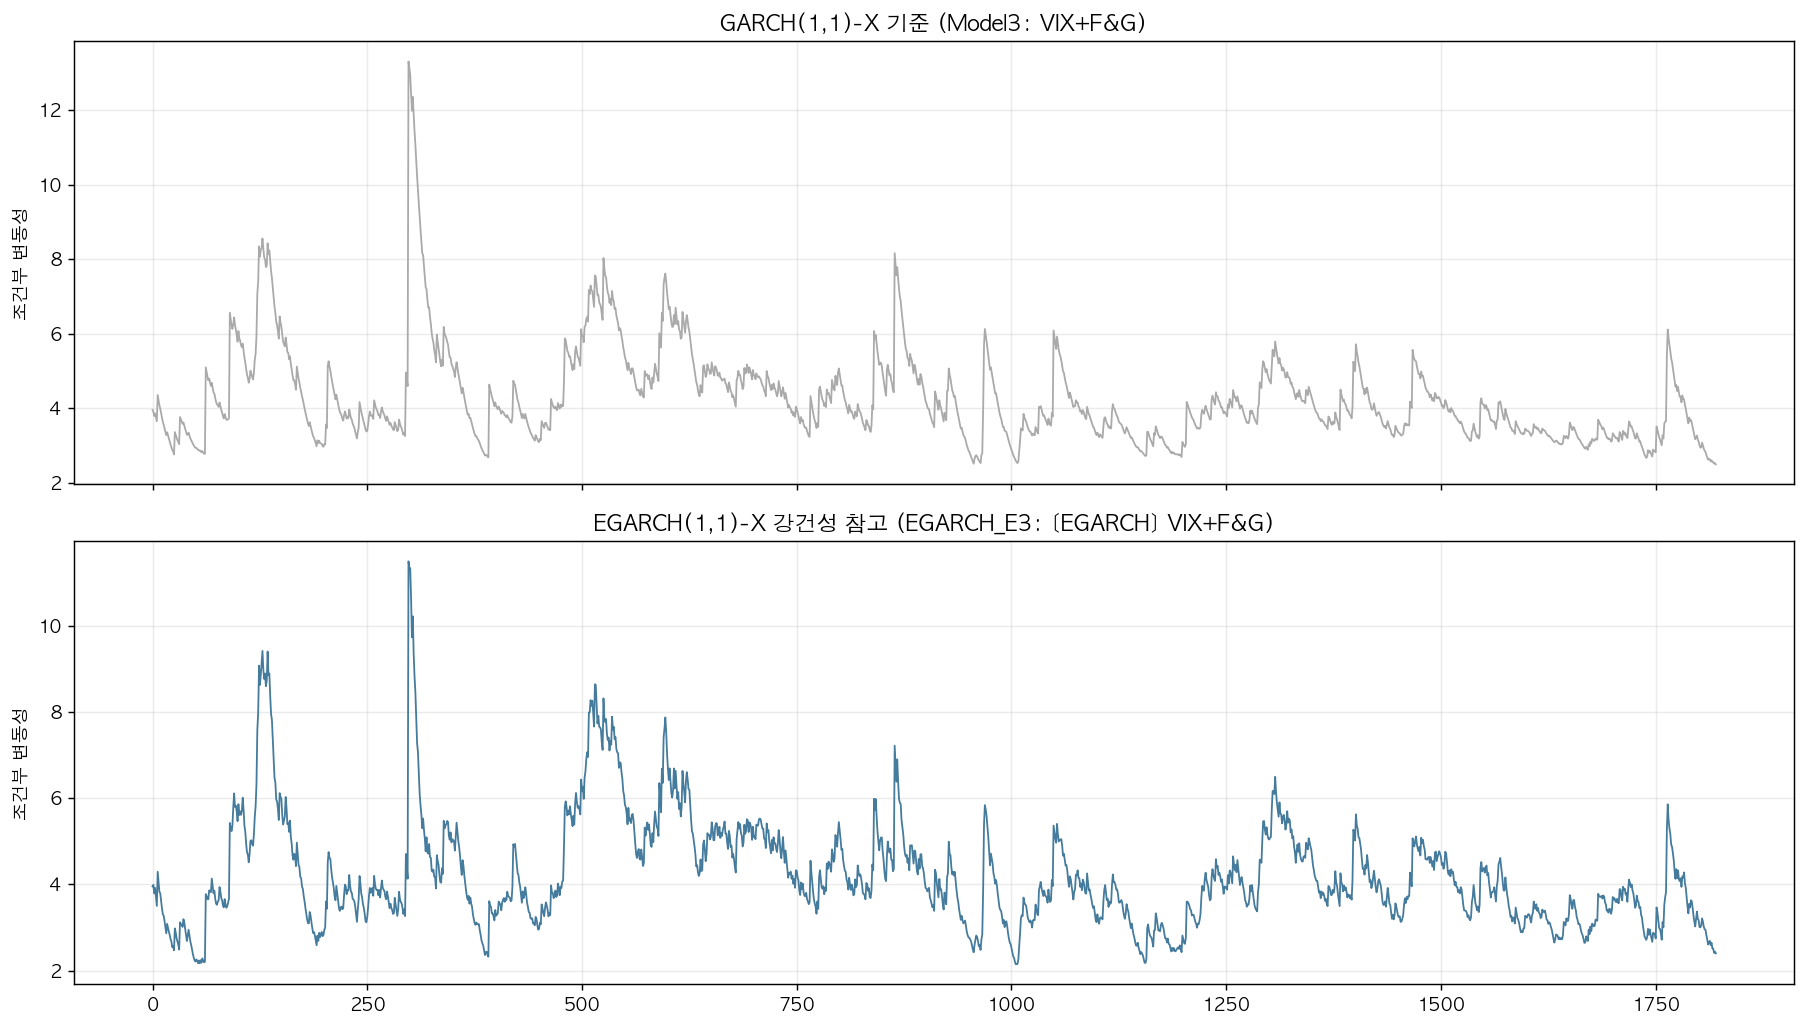

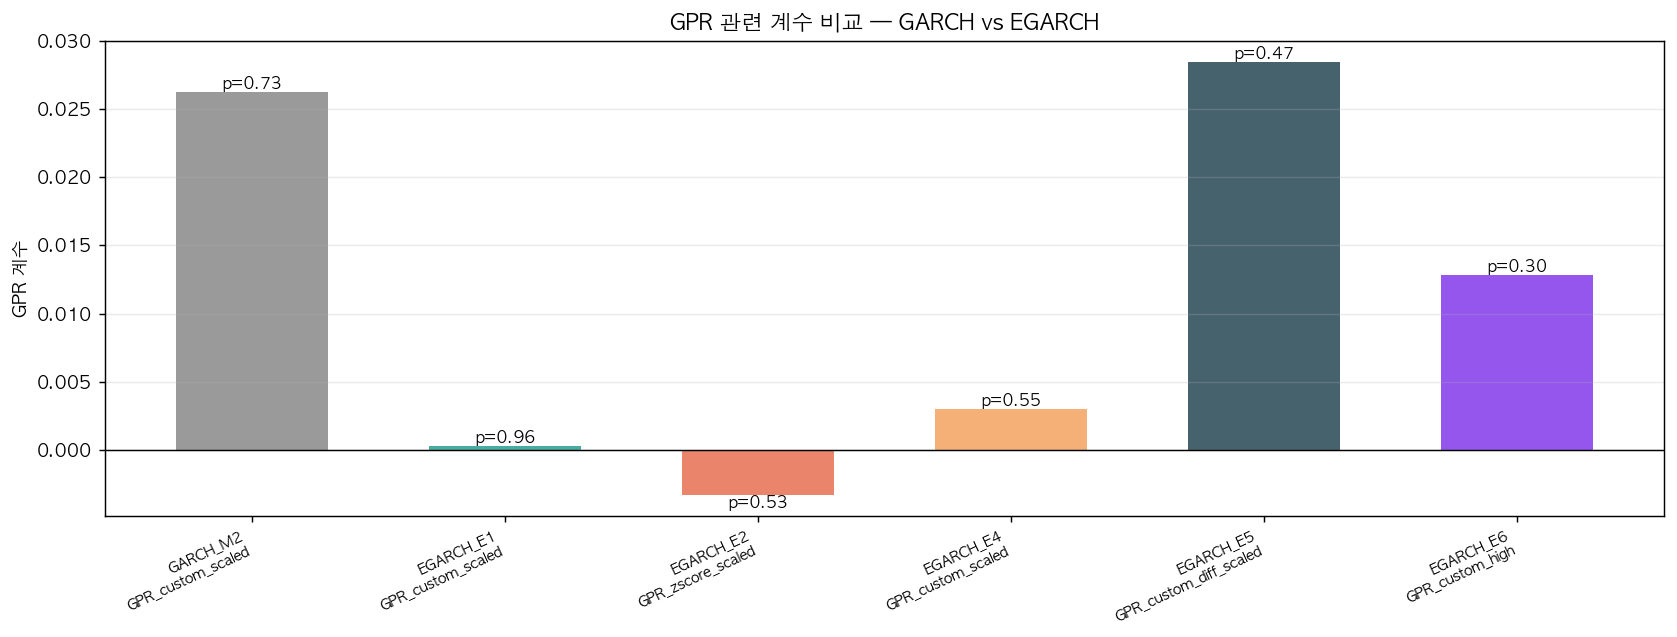

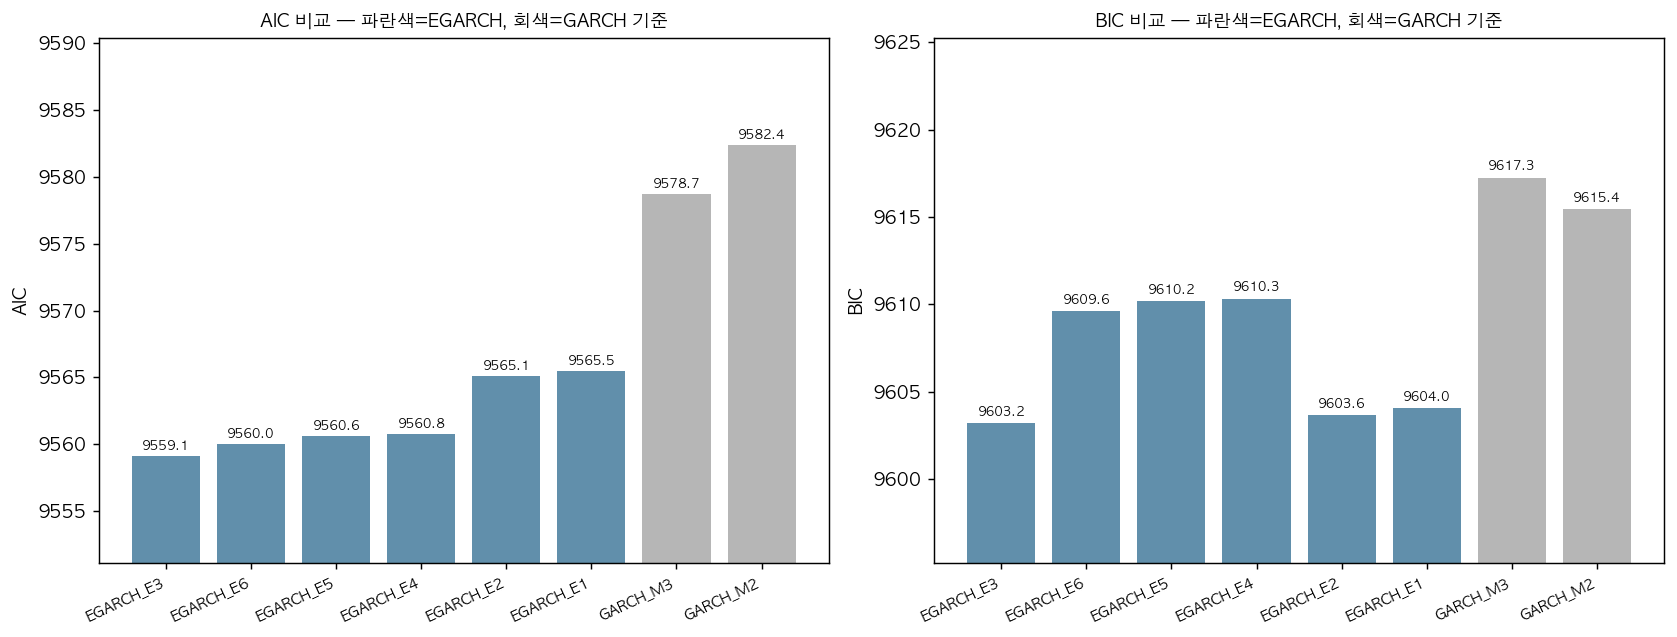

✅ egarch_model_aic_bic.png 저장


In [18]:
# 조건부 변동성 시계열: GARCH_M3 vs EGARCH 강건성 참고 모델
best_egarch = next((m for m in egarch_compare_df.index if 'EGARCH' in m), None)
if best_egarch:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for ax, mname, title in zip(
        axes,
        ['GARCH_M3', best_egarch],
        ['GARCH(1,1)-X 기준 (Model3: VIX+F&G)', f'EGARCH(1,1)-X 강건성 참고 ({best_egarch}: {EGARCH_LABELS[best_egarch]})']):
        res = all_results[mname]
        cv = res['cond_vol']
        ax.plot(range(len(cv)), cv.values, color=EGARCH_COLORS.get(mname, 'gray'), linewidth=1.0)
        ax.set_title(title)
        ax.set_ylabel('조건부 변동성')
        ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig('egarch_cond_vol_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()

# GPR 관련 계수 비교
gpr_mask = exog_df_summary['var'].str.contains('GPR|gpr', case=False, na=False)
gpr_df = exog_df_summary[gpr_mask].copy()
if len(gpr_df) > 0:
    fig, ax = plt.subplots(figsize=(13, 5))
    colors = [EGARCH_COLORS.get(r['model'], 'gray') for _, r in gpr_df.iterrows()]
    ax.bar(range(len(gpr_df)), gpr_df['coef'], color=colors, width=0.6, alpha=0.85)
    for i, (_, row) in enumerate(gpr_df.iterrows()):
        pv = row['pvalue']
        sig = '***' if pv < 0.01 else ('**' if pv < 0.05 else ('*' if pv < 0.10 else ''))
        ax.text(i, row['coef'], sig if sig else f'p={pv:.2f}', ha='center', va='bottom' if row['coef'] >= 0 else 'top', fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(gpr_df)))
    ax.set_xticklabels([f"{r['model']}\n{r['var']}" for _, r in gpr_df.iterrows()], rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('GPR 계수')
    ax.set_title('GPR 관련 계수 비교 — GARCH vs EGARCH')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig('egarch_gpr_coef_compare.png', dpi=200, bbox_inches='tight')
    plt.show()

# ── 8-3. AIC/BIC 비교 ──
# 기존 GARCH_EGARCH_비교분석.ipynb와 같은 눈금 방식 사용
compare_df_b6 = egarch_compare_df
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['AIC', 'BIC']):
    vals   = compare_df_b6[metric]
    colors = [('#457B9D' if 'EGARCH' in m else '#AAAAAA') for m in compare_df_b6.index]
    ax.bar(range(len(vals)), vals, color=colors, alpha=0.85)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(compare_df_b6.index, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} 비교 — 파란색=EGARCH, 회색=GARCH 기준', fontsize=10)
    mn = vals.min()
    ax.set_ylim(mn - 8, vals.max() + 8)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('egarch_model_aic_bic.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ egarch_model_aic_bic.png 저장')

---
## Step 11. GARCH 기본 결과 시각화

### 그래프 3종

```
11-1. 조건부 변동성 σ(t) 시계열
     → 이벤트별 경계선 포함, 각 모델의 변동성 패턴 비교

11-2. γ 계수 막대그래프
     → 외생변수별 BTC 변동성 영향 방향과 크기 비교
     → * 표시: p<0.05 유의, ⚠️: t-stat 이상

11-3. AIC / BIC 비교
     → 모델별 적합도 비교, 최적 모델 강조 (빨간 숫자)
```

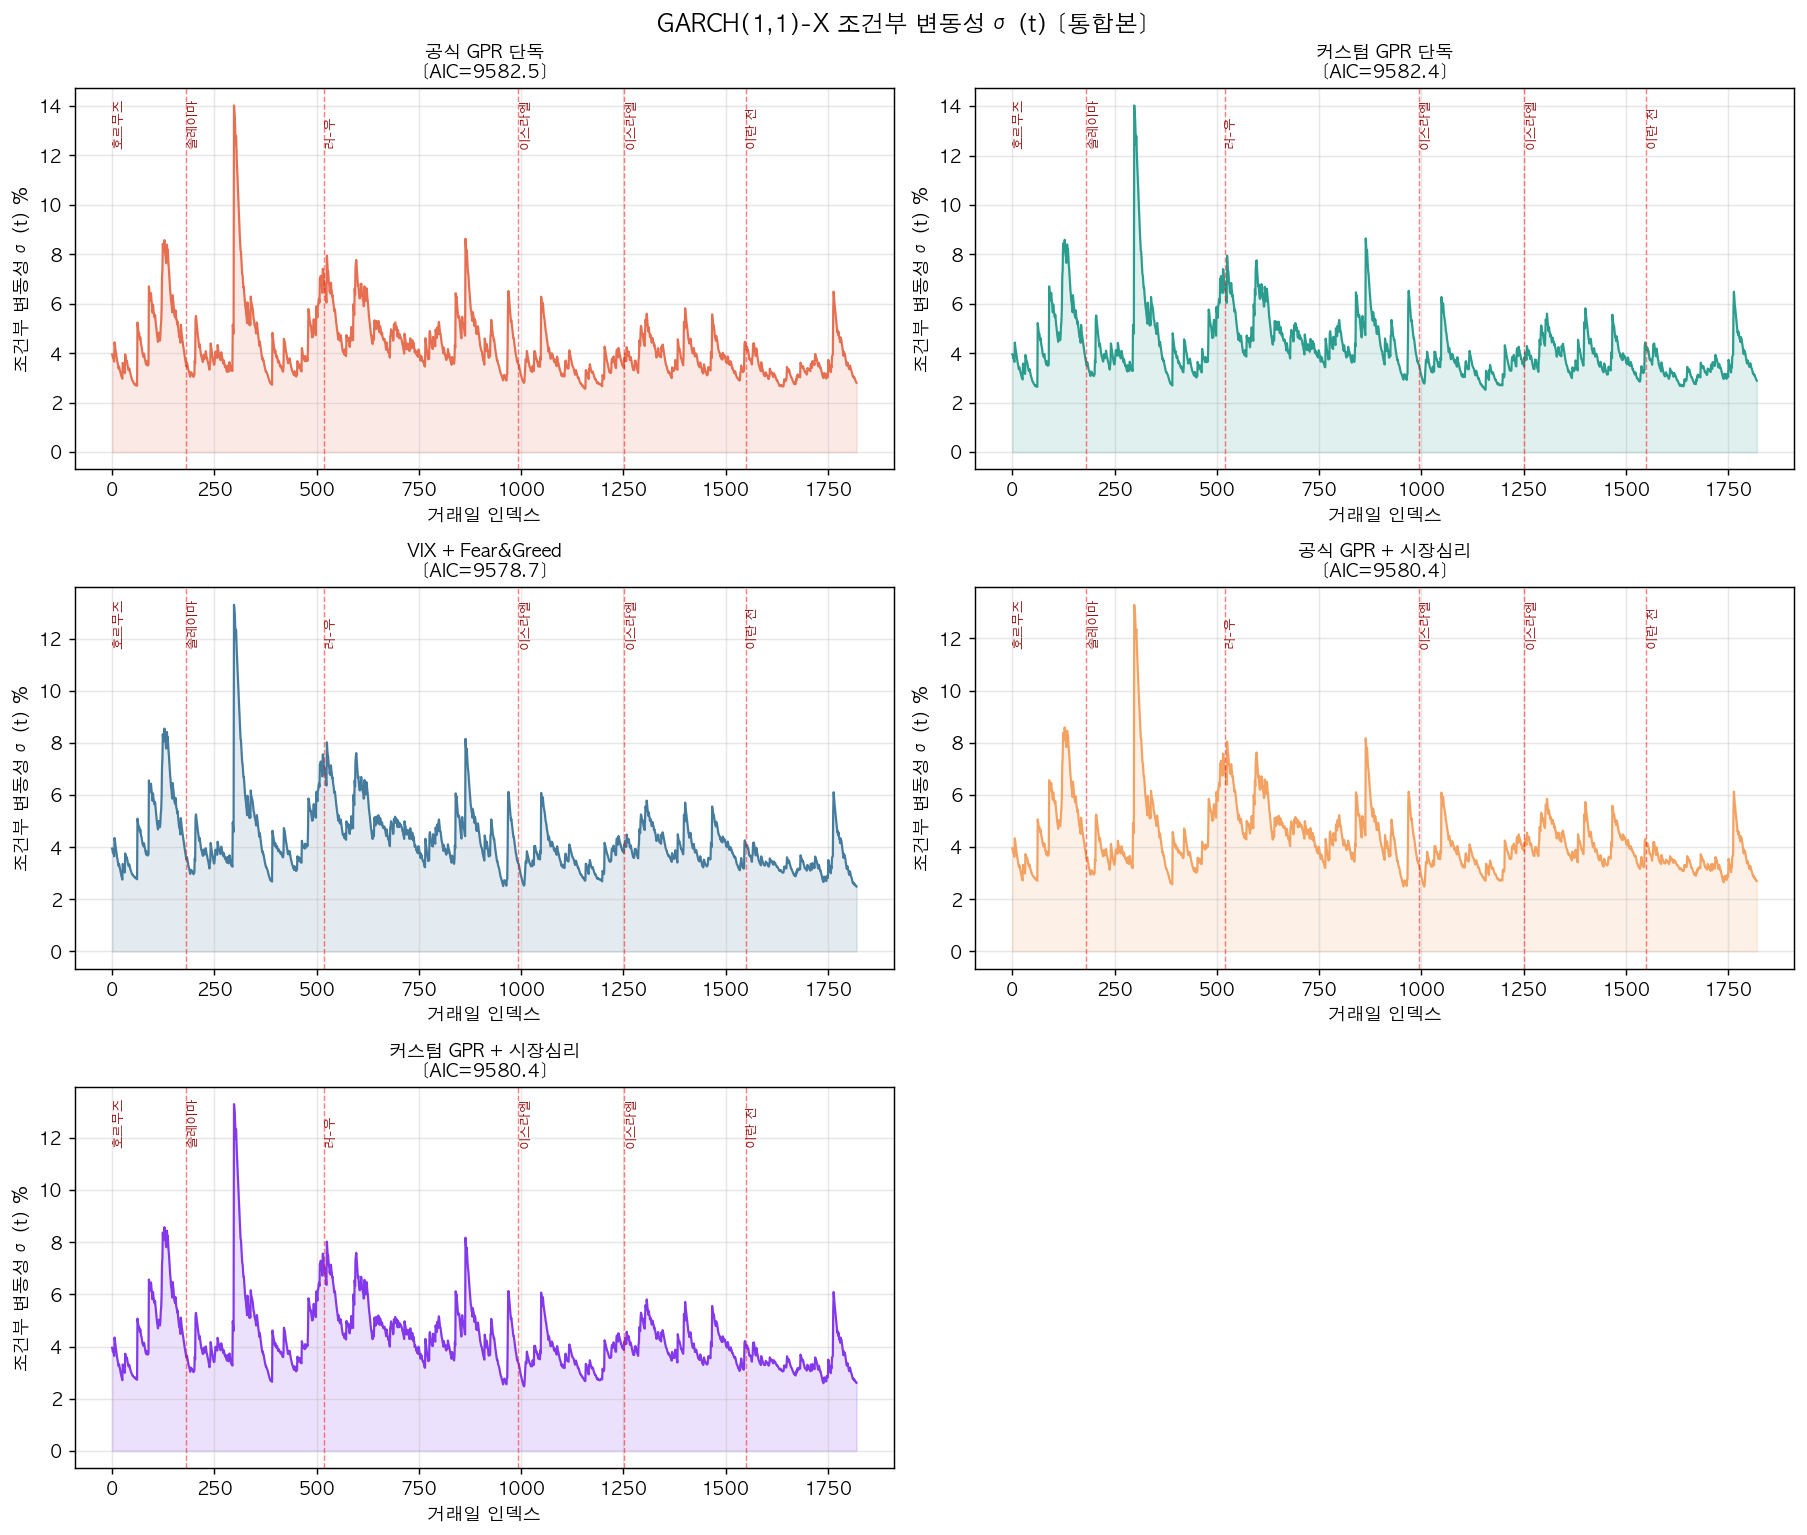

✅ garch_conditional_vol.png 저장


In [19]:
# ── 11-1. 조건부 변동성 σ(t) 시계열 ─────────────────
valid = [(m,r) for m,r in garch_results.items() if r.get('cond_vol') is not None]
n = len(valid)
cols_g = min(n,2); rows_g = (n+1)//2
fig, axes = plt.subplots(rows_g, cols_g, figsize=(14,4*rows_g), squeeze=False)
axes_flat = axes.flatten()

# 이벤트 경계 인덱스
boundaries = []
cumsum = 0
for ev in EVENT_DATES:
    cnt = (master_final['event_name']==ev).sum()
    boundaries.append((cumsum, ev))
    cumsum += cnt

for idx, (mname, res) in enumerate(valid):
    ax  = axes_flat[idx]
    cv  = res['cond_vol']
    clr = MODEL_COLORS.get(mname,'steelblue')
    ax.plot(cv, color=clr, lw=1.2, label='σ(t)')
    ax.fill_between(range(len(cv)), cv, alpha=0.15, color=clr)
    for pos, ev in boundaries[1:]:
        ax.axvline(pos, color='red', lw=0.8, ls='--', alpha=0.5)
    ymax = np.nanmax(cv)
    for pos, ev in boundaries:
        if pos < len(cv):
            ax.text(pos+0.5, ymax*0.88,
                    EVENT_LABELS.get(ev,ev)[:4],
                    fontsize=7, color='darkred', rotation=90)
    ax.set_title(
        f'{MODEL_LABELS.get(mname,mname)}\n[AIC={res["aic"]:.1f}]',
        fontsize=10, fontweight='bold')
    ax.set_xlabel('거래일 인덱스')
    ax.set_ylabel('조건부 변동성 σ(t) %')
    ax.grid(alpha=0.3)

for ax in axes_flat[len(valid):]: ax.set_visible(False)

plt.suptitle('GARCH(1,1)-X 조건부 변동성 σ(t) [통합본]',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('garch_conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ garch_conditional_vol.png 저장')

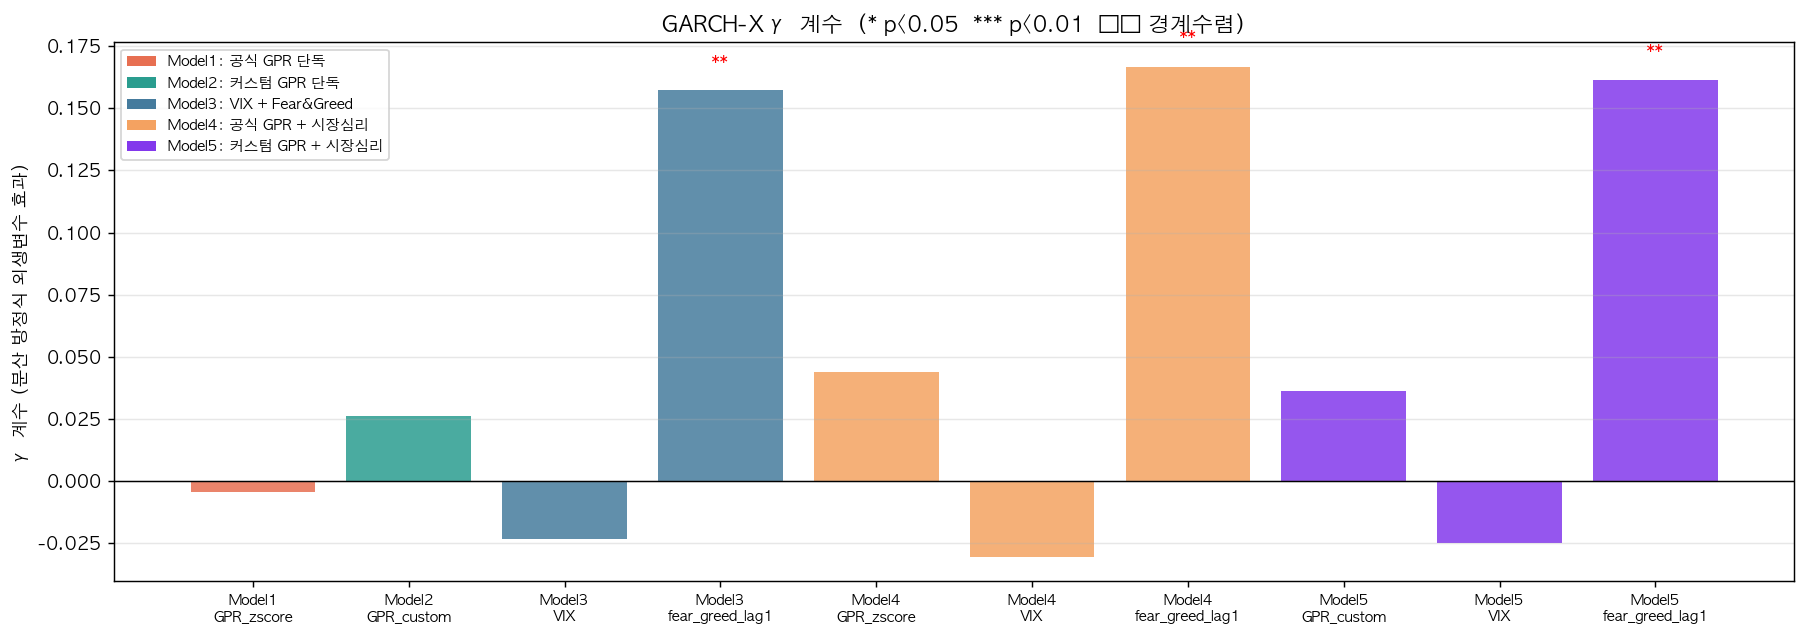

✅ garch_gamma_coefficients.png 저장


In [20]:
# ── 11-2. γ 계수 막대그래프 ──────────────────────────
if len(gamma_df) > 0:
    fig, ax = plt.subplots(figsize=(14,5))
    clrs = [MODEL_COLORS.get(r['model'],'gray') for _,r in gamma_df.iterrows()]
    bars = ax.bar(range(len(gamma_df)), gamma_df['gamma'].values, color=clrs, alpha=0.85)
    for bar, (_,row) in zip(bars, gamma_df.iterrows()):
        pv = row['p_value']
        sig = ('***' if pv<0.01 else '**' if pv<0.05 else '*' if pv<0.10 else '')
        if sig and '⚠️' not in row['significance']:
            yoff = abs(bar.get_height())*0.05*(1 if bar.get_height()>=0 else -1)
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+yoff, sig,
                    ha='center', fontsize=11, color='red')
        if '⚠️' in str(row['significance']):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()*0.5, '⚠️',
                    ha='center', fontsize=9)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(gamma_df)))
    ax.set_xticklabels(
        [f'{r["model"]}\n{r["variable"].replace("_scaled","")}'
         for _,r in gamma_df.iterrows()], fontsize=8)
    ax.set_ylabel('γ 계수 (분산 방정식 외생변수 효과)')
    ax.set_title('GARCH-X γ 계수  (* p<0.05  *** p<0.01  ⚠️ 경계수렴)', fontsize=12)
    legend_els = [Patch(facecolor=v, label=f'{k}: {MODEL_LABELS[k]}')
                  for k,v in MODEL_COLORS.items() if k in gamma_df['model'].values]
    ax.legend(handles=legend_els, fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('garch_gamma_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ garch_gamma_coefficients.png 저장')

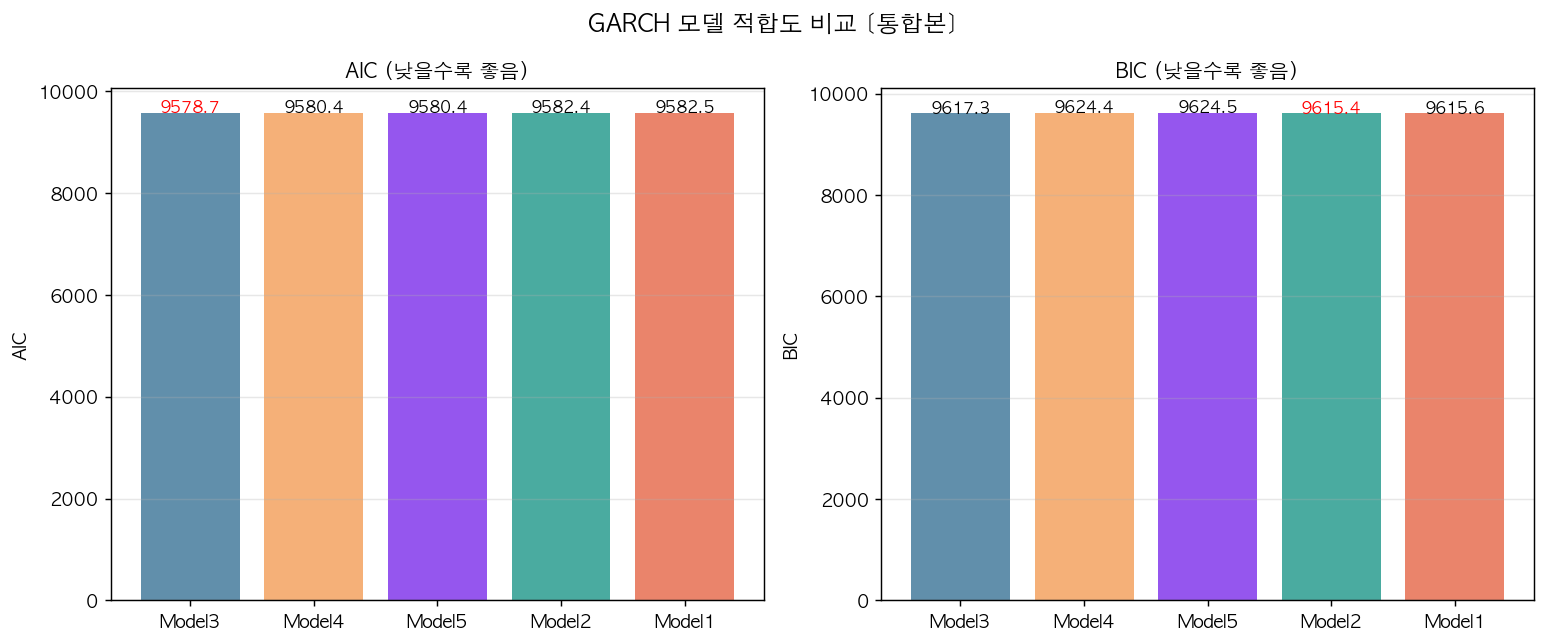

✅ garch_model_comparison.png 저장


In [21]:
# ── 11-3. AIC / BIC 비교 ─────────────────────────────
if len(compare_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    for ax, metric in zip(axes, ['AIC','BIC']):
        vals  = compare_df[metric].values
        clrs2 = [MODEL_COLORS.get(m,'gray') for m in compare_df.index]
        bars  = ax.bar(compare_df.index, vals, color=clrs2, alpha=0.85)
        bv    = vals.min()
        for bar, val in zip(bars, vals):
            fc = 'red' if val==bv else 'black'
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.3,
                    f'{val:.1f}', ha='center', fontsize=9, color=fc)
        ax.set_title(f'{metric} (낮을수록 좋음)', fontsize=11)
        ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    plt.suptitle('GARCH 모델 적합도 비교 [통합본]', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('garch_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ garch_model_comparison.png 저장')

---
## Step 12. GARCH 및 통합 결과 저장

### 저장 파일 목록

| 파일 | 내용 |
|---|---|
| `garch_model_comparison.csv` | GARCH 모델별 AIC/BIC/LogLik 비교 |
| `garch_gamma_results.csv` | GARCH γ 계수 + p-value 요약 |
| `garch_model_params.csv` | GARCH 전체 파라미터 상세 |
| `garch_event_dummy_comparison.csv` | 이벤트 더미 강건성 검증 결과 |
| `egarch_model_comparison.csv` | EGARCH 강건성 검증 모델 비교 |
| `egarch_exog_coefficients.csv` | EGARCH 외생변수 계수 및 p-value |
| `garch_egarch_integrated_summary.csv` | GARCH/이벤트 더미/EGARCH 통합 요약 |
| `egarch_step_b3_coefficients_long.csv` | Step 10-3 추정 계수 long format |
| `egarch_step_b3_coefficients_wide.csv` | Step 10-3 추정 계수 wide format |
| `garch_conditional_volatility.csv` | 최적 GARCH 조건부 변동성 시계열 |
| `garch_conditional_vol.png` | GARCH 조건부 변동성 시각화 |
| `garch_gamma_coefficients.png` | GARCH γ 계수 비교 |
| `garch_model_comparison.png` | GARCH AIC/BIC 비교 |
| `egarch_model_aic_bic.png` | EGARCH 강건성 AIC/BIC 비교 |


In [22]:
compare_df.to_csv('garch_model_comparison.csv', encoding='utf-8-sig')
if len(gamma_df)>0:
    gamma_df.to_csv('garch_gamma_results.csv', index=False, encoding='utf-8-sig')
if 'event_dummy_compare_df' in dir() and len(event_dummy_compare_df)>0:
    event_dummy_compare_df.to_csv('garch_event_dummy_comparison.csv', index=False, encoding='utf-8-sig')

# 전체 파라미터 저장 (민진 수정본 채택)
param_rows = []
for mname, res in garch_results.items():
    if res.get('error') or res.get('result') is None: continue
    pvs = res.get('stats',{}).get('p_values')
    ses = res.get('stats',{}).get('se')
    for i, pname in enumerate(res['param_names']):
        param_rows.append({
            'model'      : mname,
            'model_label': MODEL_LABELS.get(mname,mname),
            'param'      : pname,
            'estimate'   : res['result'].x[i],
            'se'         : ses[i] if ses is not None else np.nan,
            'p_value'    : pvs[i] if pvs is not None else np.nan,
            'converged'  : res['converged'],
            'loglik'     : res['loglik'],
            'AIC'        : res['aic'],
            'BIC'        : res['bic'],
        })
pd.DataFrame(param_rows).to_csv('garch_model_params.csv',
                                  index=False, encoding='utf-8-sig')

# 최적 모델 조건부 변동성
if len(compare_df) > 0:
    best_res = garch_results[compare_df.index[0]]
    if best_res.get('cond_vol') is not None:
        idx = best_res['y_index']
        pd.DataFrame({
            'date'          : master_final.loc[idx,'date'].values,
            'event_name'    : master_final.loc[idx,'event_name'].values,
            'BTC_return_pct': master_final.loc[idx,'returns_pct'].values,
            'best_model'    : compare_df.index[0],
            'cond_vol'      : best_res['cond_vol'],
        }).to_csv('garch_conditional_volatility.csv',
                   index=False, encoding='utf-8-sig')

print('▶ 저장 파일 확인:')
for f in ['garch_model_comparison.csv','garch_gamma_results.csv',
          'garch_model_params.csv','garch_event_dummy_comparison.csv',
          'garch_conditional_volatility.csv',
          'garch_conditional_vol.png','garch_gamma_coefficients.png',
          'garch_model_comparison.png']:
    flag = '✅' if os.path.exists(f) else '📄 (실행 후 생성)'
    print(f'  {flag} {f}')


▶ 저장 파일 확인:
  ✅ garch_model_comparison.csv
  ✅ garch_gamma_results.csv
  ✅ garch_model_params.csv
  ✅ garch_event_dummy_comparison.csv
  ✅ garch_conditional_volatility.csv
  ✅ garch_conditional_vol.png
  ✅ garch_gamma_coefficients.png
  ✅ garch_model_comparison.png


In [23]:
# 통합 결과 저장
egarch_compare_df.to_csv('egarch_model_comparison.csv', encoding='utf-8-sig')
if len(exog_df_summary) > 0:
    exog_df_summary.to_csv('egarch_exog_coefficients.csv', index=False, encoding='utf-8-sig')

integrated_summary_rows = []
# GARCH 기본 비교
if 'compare_df' in dir():
    for model, row in compare_df.iterrows():
        integrated_summary_rows.append({
            'section': 'GARCH 기본', 'model': model,
            'label': MODEL_LABELS.get(model, model),
            'AIC': row['AIC'], 'BIC': row['BIC'],
            'LogLik': row['Log-Lik'] if 'Log-Lik' in row else np.nan,
        })
# 이벤트 더미 비교
if 'event_dummy_compare_df' in dir():
    for _, row in event_dummy_compare_df.iterrows():
        integrated_summary_rows.append({
            'section': '이벤트 더미 강건성', 'model': row['model'],
            'label': row['model_label'],
            'AIC': row['AIC'], 'BIC': row['BIC'], 'LogLik': row['LogLik'],
        })
# EGARCH 비교
for model, row in egarch_compare_df.iterrows():
    integrated_summary_rows.append({
        'section': 'EGARCH 강건성', 'model': model,
        'label': row['설명'],
        'AIC': row['AIC'], 'BIC': row['BIC'], 'LogLik': row['LogLik'],
    })

pd.DataFrame(integrated_summary_rows).to_csv(
    'garch_egarch_integrated_summary.csv', index=False, encoding='utf-8-sig'
)

print('▶ 통합 저장 파일:')
for f in ['garch_model_comparison.csv', 'garch_gamma_results.csv', 'garch_event_dummy_comparison.csv',
          'egarch_model_comparison.csv', 'egarch_exog_coefficients.csv', 'garch_egarch_integrated_summary.csv',
          'egarch_step_b3_coefficients_long.csv', 'egarch_step_b3_coefficients_wide.csv']:
    print(f'  {"✅" if os.path.exists(f) else "⚠️"} {f}')


▶ 통합 저장 파일:
  ✅ garch_model_comparison.csv
  ✅ garch_gamma_results.csv
  ✅ garch_event_dummy_comparison.csv
  ✅ egarch_model_comparison.csv
  ✅ egarch_exog_coefficients.csv
  ✅ garch_egarch_integrated_summary.csv
  ✅ egarch_step_b3_coefficients_long.csv
  ✅ egarch_step_b3_coefficients_wide.csv


---
## Step 13. 최종 종합 결론

## 충족한 요구사항

| 요구사항 | 통합본 반영 |
|---|---|
| p-value 높일 수 있는 방법 검토 | GPR 변환/EGARCH/부트스트랩 보조 검정 결과, GPR_custom 유의성 확보는 어려움 |
| 한계점 수정 가능성 파악 및 개선 | alpha/beta SE 안정화, omega 민감도, 다중 초기값, 이벤트 더미 강건성 검정 반영 |
| 결과 정리 및 해석 정리 | GARCH 주 분석 + 한계점 개선 + 이벤트 더미/EGARCH 강건성 검증을 하나의 흐름으로 정리 |

## 최종 해석

- 최종 분석은 `GARCH-X` 기준으로 해석
- 기본 GARCH-X에서는 `Model3: VIX + Fear&Greed`가 AIC 기준 최적
- 이벤트 더미 추가 시 AIC는 개선되지만 BIC가 악화되므로, 주모형 대체가 아니라 이벤트 표본 설계에 대한 강건성 검정으로 해석
- EGARCH는 주모형 대체가 아니라, 비대칭 변동성 구조를 고려해도 GARCH 결론이 유지되는지 확인하는 강건성 검증
- EGARCH에서도 `GPR_custom`의 독립적 유의성은 확보되지 않았고, `Fear&Greed`는 반복적으로 유의
- 핵심 결론은 `GPR_custom`보다 시장 심리 변수인 `Fear&Greed`가 BTC 변동성 설명에 더 안정적

## 최종 한계

1. `alpha+beta`가 1에 가까운 near-IGARCH 구조
2. 이벤트 중심 표본 설계의 trade-off
3. GPR_custom 독립 효과 비유의


In [24]:
print('='*80)
print('GARCH 분석 통합 최종 결론')
print('='*80)

print('\n▶ 1. GARCH-X 주 분석 결과')
print(f'  기본 GARCH-X AIC 최적: Model3 ({MODEL_LABELS.get("Model3", "VIX+F&G")})')
print(f'  AIC={compare_df.loc["Model3", "AIC"]:.3f}, BIC={compare_df.loc["Model3", "BIC"]:.3f}')
print('  GPR_custom: Model2/Model5 모두 비유의')
print('  Fear&Greed: Model3/Model5에서 반복적으로 유의')

if 'event_dummy_compare_df' in dir():
    ed_best = event_dummy_compare_df.iloc[0]
    print('\n▶ 2. 이벤트 더미 강건성 검증')
    print(f'  최저 AIC: {ed_best["model"]}  AIC={ed_best["AIC"]:.3f}, BIC={ed_best["BIC"]:.3f}')
    print('  AIC는 개선되지만 BIC는 악화 → 주모형 대체가 아니라 이벤트별 구조 차이 보완 확인')

print('\n▶ 3. EGARCH 강건성 검증')
print(f'  EGARCH 내 최저 AIC 참고 모델: {best_egarch_only} ({EGARCH_LABELS[best_egarch_only]})')
print(f'  AIC={egarch_compare_df.loc[best_egarch_only,"AIC"]:.3f}, BIC={egarch_compare_df.loc[best_egarch_only,"BIC"]:.3f}')
print(f'  GARCH_M3 대비 참고 ΔAIC={egarch_compare_df.loc[best_egarch_only,"AIC"] - egarch_compare_df.loc["GARCH_M3","AIC"]:+.3f}')

print('\n▶ 최종 요약')
print('  1) 최종 해석의 중심은 GARCH-X 주 분석')
print('  2) 이벤트 더미와 EGARCH는 결론 유지 여부를 확인하는 강건성 검증')
print('  3) GARCH/EGARCH 모두 GPR_custom 독립 효과는 비유의')
print('  4) Fear&Greed는 반복적으로 유의 → BTC 변동성 설명력이 더 안정적')
print('  5) 최종 한계: near-IGARCH, 이벤트 중심 표본 trade-off, GPR_custom 비유의')


GARCH 분석 통합 최종 결론

▶ 1. GARCH-X 주 분석 결과
  기본 GARCH-X AIC 최적: Model3 (VIX + Fear&Greed)
  AIC=9578.710, BIC=9617.260
  GPR_custom: Model2/Model5 모두 비유의
  Fear&Greed: Model3/Model5에서 반복적으로 유의

▶ 2. 이벤트 더미 강건성 검증
  최저 AIC: Model3_eventD  AIC=9569.545, BIC=9635.631
  AIC는 개선되지만 BIC는 악화 → 주모형 대체가 아니라 이벤트별 구조 차이 보완 확인

▶ 3. EGARCH 강건성 검증
  EGARCH 내 최저 AIC 참고 모델: EGARCH_E3 ([EGARCH] VIX+F&G)
  AIC=9559.119, BIC=9603.176
  GARCH_M3 대비 참고 ΔAIC=-19.591

▶ 최종 요약
  1) 최종 해석의 중심은 GARCH-X 주 분석
  2) 이벤트 더미와 EGARCH는 결론 유지 여부를 확인하는 강건성 검증
  3) GARCH/EGARCH 모두 GPR_custom 독립 효과는 비유의
  4) Fear&Greed는 반복적으로 유의 → BTC 변동성 설명력이 더 안정적
  5) 최종 한계: near-IGARCH, 이벤트 중심 표본 trade-off, GPR_custom 비유의
